# Chapter 7 - Choosing the Right Model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 600

In [2]:
df = pd.read_csv('../raw_data/kc_house_data/kc_house_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [4]:
hist = df.hist(bins=50, figsize=(40,30))

In [5]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state  = 1)

In [6]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


<AxesSubplot:xlabel='long', ylabel='lat'>

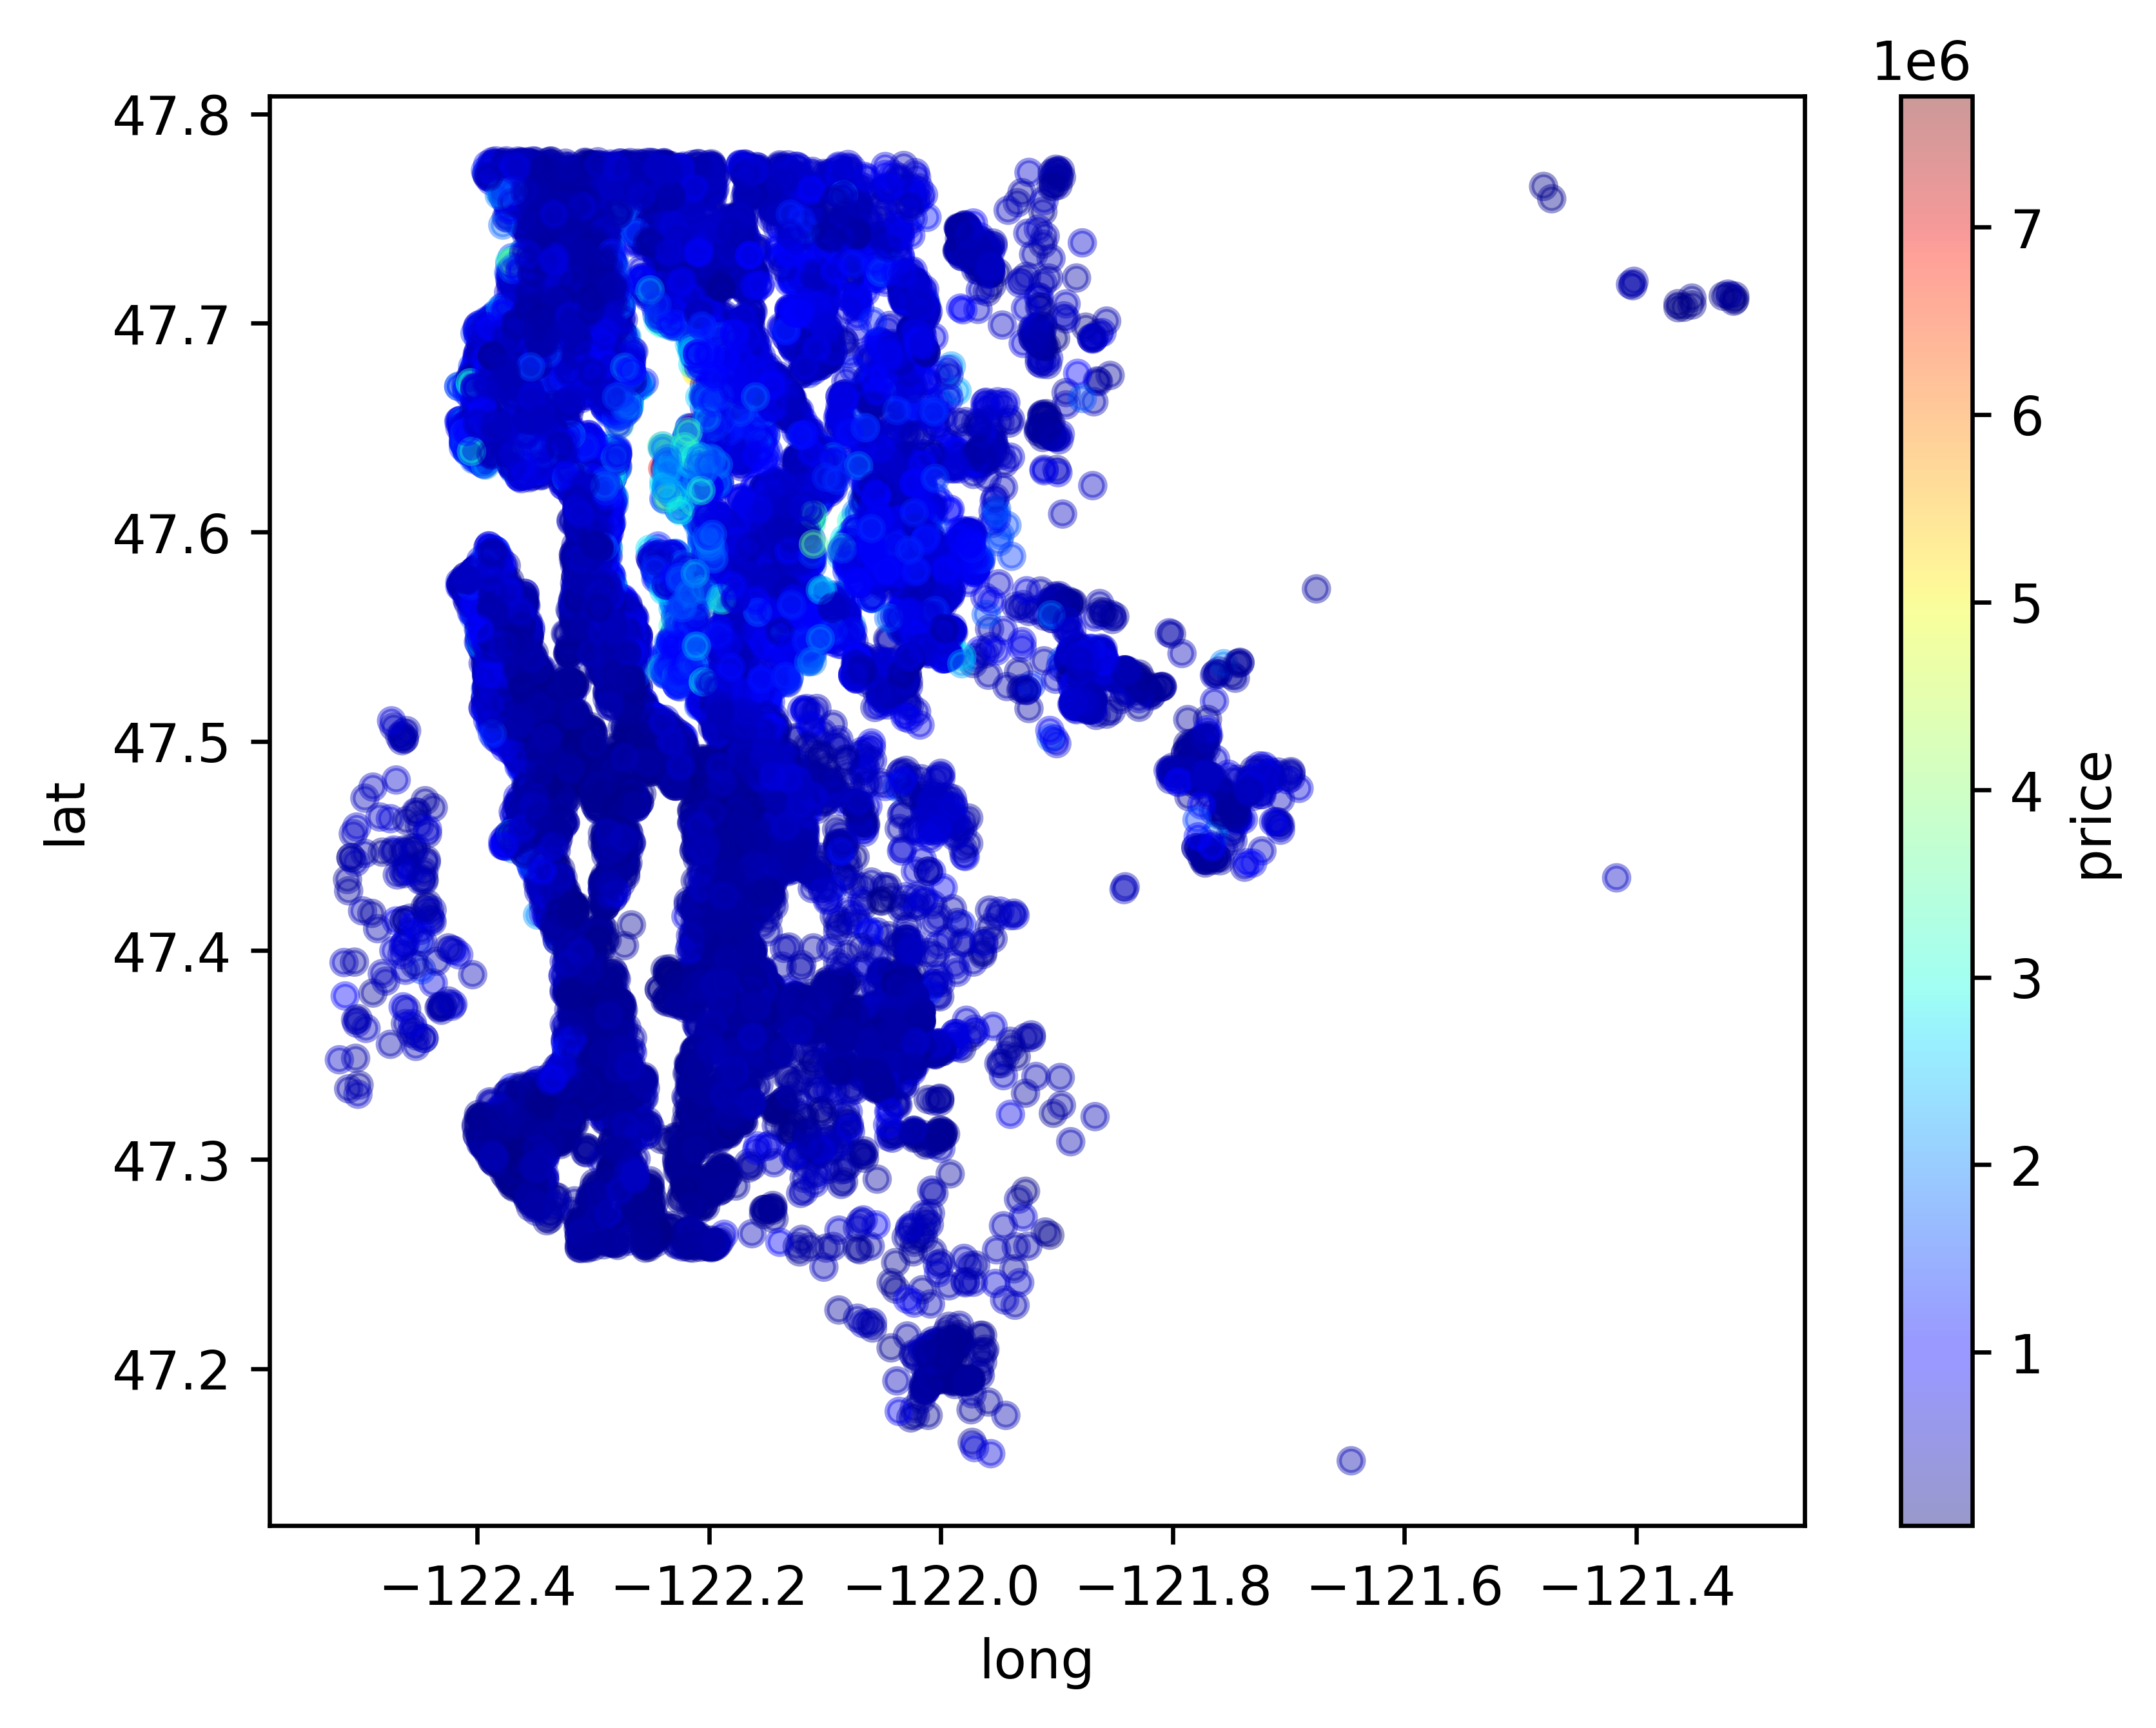

In [7]:
df.plot(kind = 'scatter', x='long', y='lat', alpha=0.4, 
#         s='sqft_living'/100,
         c='price', cmap=plt.get_cmap("jet"))

In [8]:
df.corr()['price'].sort_values(ascending=False)

/tmp/ipykernel_71248/1745294458.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['price'].sort_values(ascending=False)


price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64

## Linear Regression

In [9]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split

training_data = df.drop('price',axis=1)
training_data.drop(columns='date',axis=1, inplace=True)
target = df['price']

In [10]:
target.describe()

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

In [11]:
train_features, test_features, train_target, test_target = train_test_split(training_data, target, test_size = 0.2, random_state=5) 
train_features

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
3856,8556800100,4,2.50,2880,23994,2.0,0,3,3,9,2880,0,2002,0,98022,47.2124,-122.005,2470,17009
5010,8132700185,2,1.00,620,4455,1.0,0,0,3,6,620,0,1927,0,98117,47.6877,-122.395,1180,5000
18050,7701961220,4,2.50,2990,16809,2.0,0,0,3,11,2990,0,1990,0,98077,47.7123,-122.073,3340,18752
570,5104510270,4,2.50,1830,5612,2.0,0,0,3,7,1830,0,2003,0,98038,47.3572,-122.015,1830,5998
8556,8965500880,4,2.50,3320,9380,2.0,0,3,3,10,3320,0,1988,0,98006,47.5655,-122.114,2870,11779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5520,2877101100,3,1.75,2100,5000,1.5,0,0,3,8,2100,0,1916,0,98117,47.6776,-122.360,1830,4200
3046,9206200110,3,1.00,1330,10500,1.0,0,0,3,7,960,370,1963,0,98034,47.7204,-122.196,1460,11550
20463,2011400401,3,2.50,2730,7136,2.0,0,0,3,8,2730,0,2012,0,98198,47.3938,-122.321,2130,8932
18638,1189000910,2,1.50,1920,3408,1.0,0,0,4,7,960,960,1912,0,98122,47.6118,-122.299,1130,3408


In [12]:
regr = linear_model.LinearRegression()
regr.fit(train_features,train_target)

LinearRegression()

In [13]:
y_predict = regr.predict(test_features)

In [14]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
print(data.feature_names)
print(data.data[:5])

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
[[ 0.03807591  0.05068012  0.06169621  0.02187235 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990842 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632783 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06832974 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567061 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286377 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665645  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02269202 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187235  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03199144 -0.04664087]]


## SVMs

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

# Load the diabetes dataset
diabetes_X,diabetes_y = datasets.load_diabetes(as_frame=True, return_X_y = True)

# diabetes_y = pd.DataFrame(diabetes_target,columns=['severity'])
# print(diabetes_y)


# df = pd.merge(diabetes_X,diabetes_y, left_index=True, right_index=True)
df.head()
df.describe

<bound method NDFrame.describe of                id             date     price  bedrooms  bathrooms  \
0      7129300520  20141013T000000  221900.0         3       1.00   
1      6414100192  20141209T000000  538000.0         3       2.25   
2      5631500400  20150225T000000  180000.0         2       1.00   
3      2487200875  20141209T000000  604000.0         4       3.00   
4      1954400510  20150218T000000  510000.0         3       2.00   
...           ...              ...       ...       ...        ...   
21608   263000018  20140521T000000  360000.0         3       2.50   
21609  6600060120  20150223T000000  400000.0         4       2.50   
21610  1523300141  20140623T000000  402101.0         2       0.75   
21611   291310100  20150116T000000  400000.0         3       2.50   
21612  1523300157  20141015T000000  325000.0         2       0.75   

       sqft_living  sqft_lot  floors  waterfront  view  ...  grade  \
0             1180      5650     1.0           0     0  ...      7 

### Use Diabetes dataset

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets


data = datasets.load_diabetes(as_frame=True)

diabetes_X = pd.DataFrame(data['data'])

diabetes_y = data['target']

train_features, test_features, train_target, test_target = train_test_split(diabetes_X, diabetes_y, test_size=.2, random_state=33)

train_target.head()

114    258.0
363     58.0
1       75.0
343    113.0
258     89.0
Name: target, dtype: float64

[200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200.
 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200.
 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200.
 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200.
 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200.
 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200.
 200. 200. 200. 200. 200.]


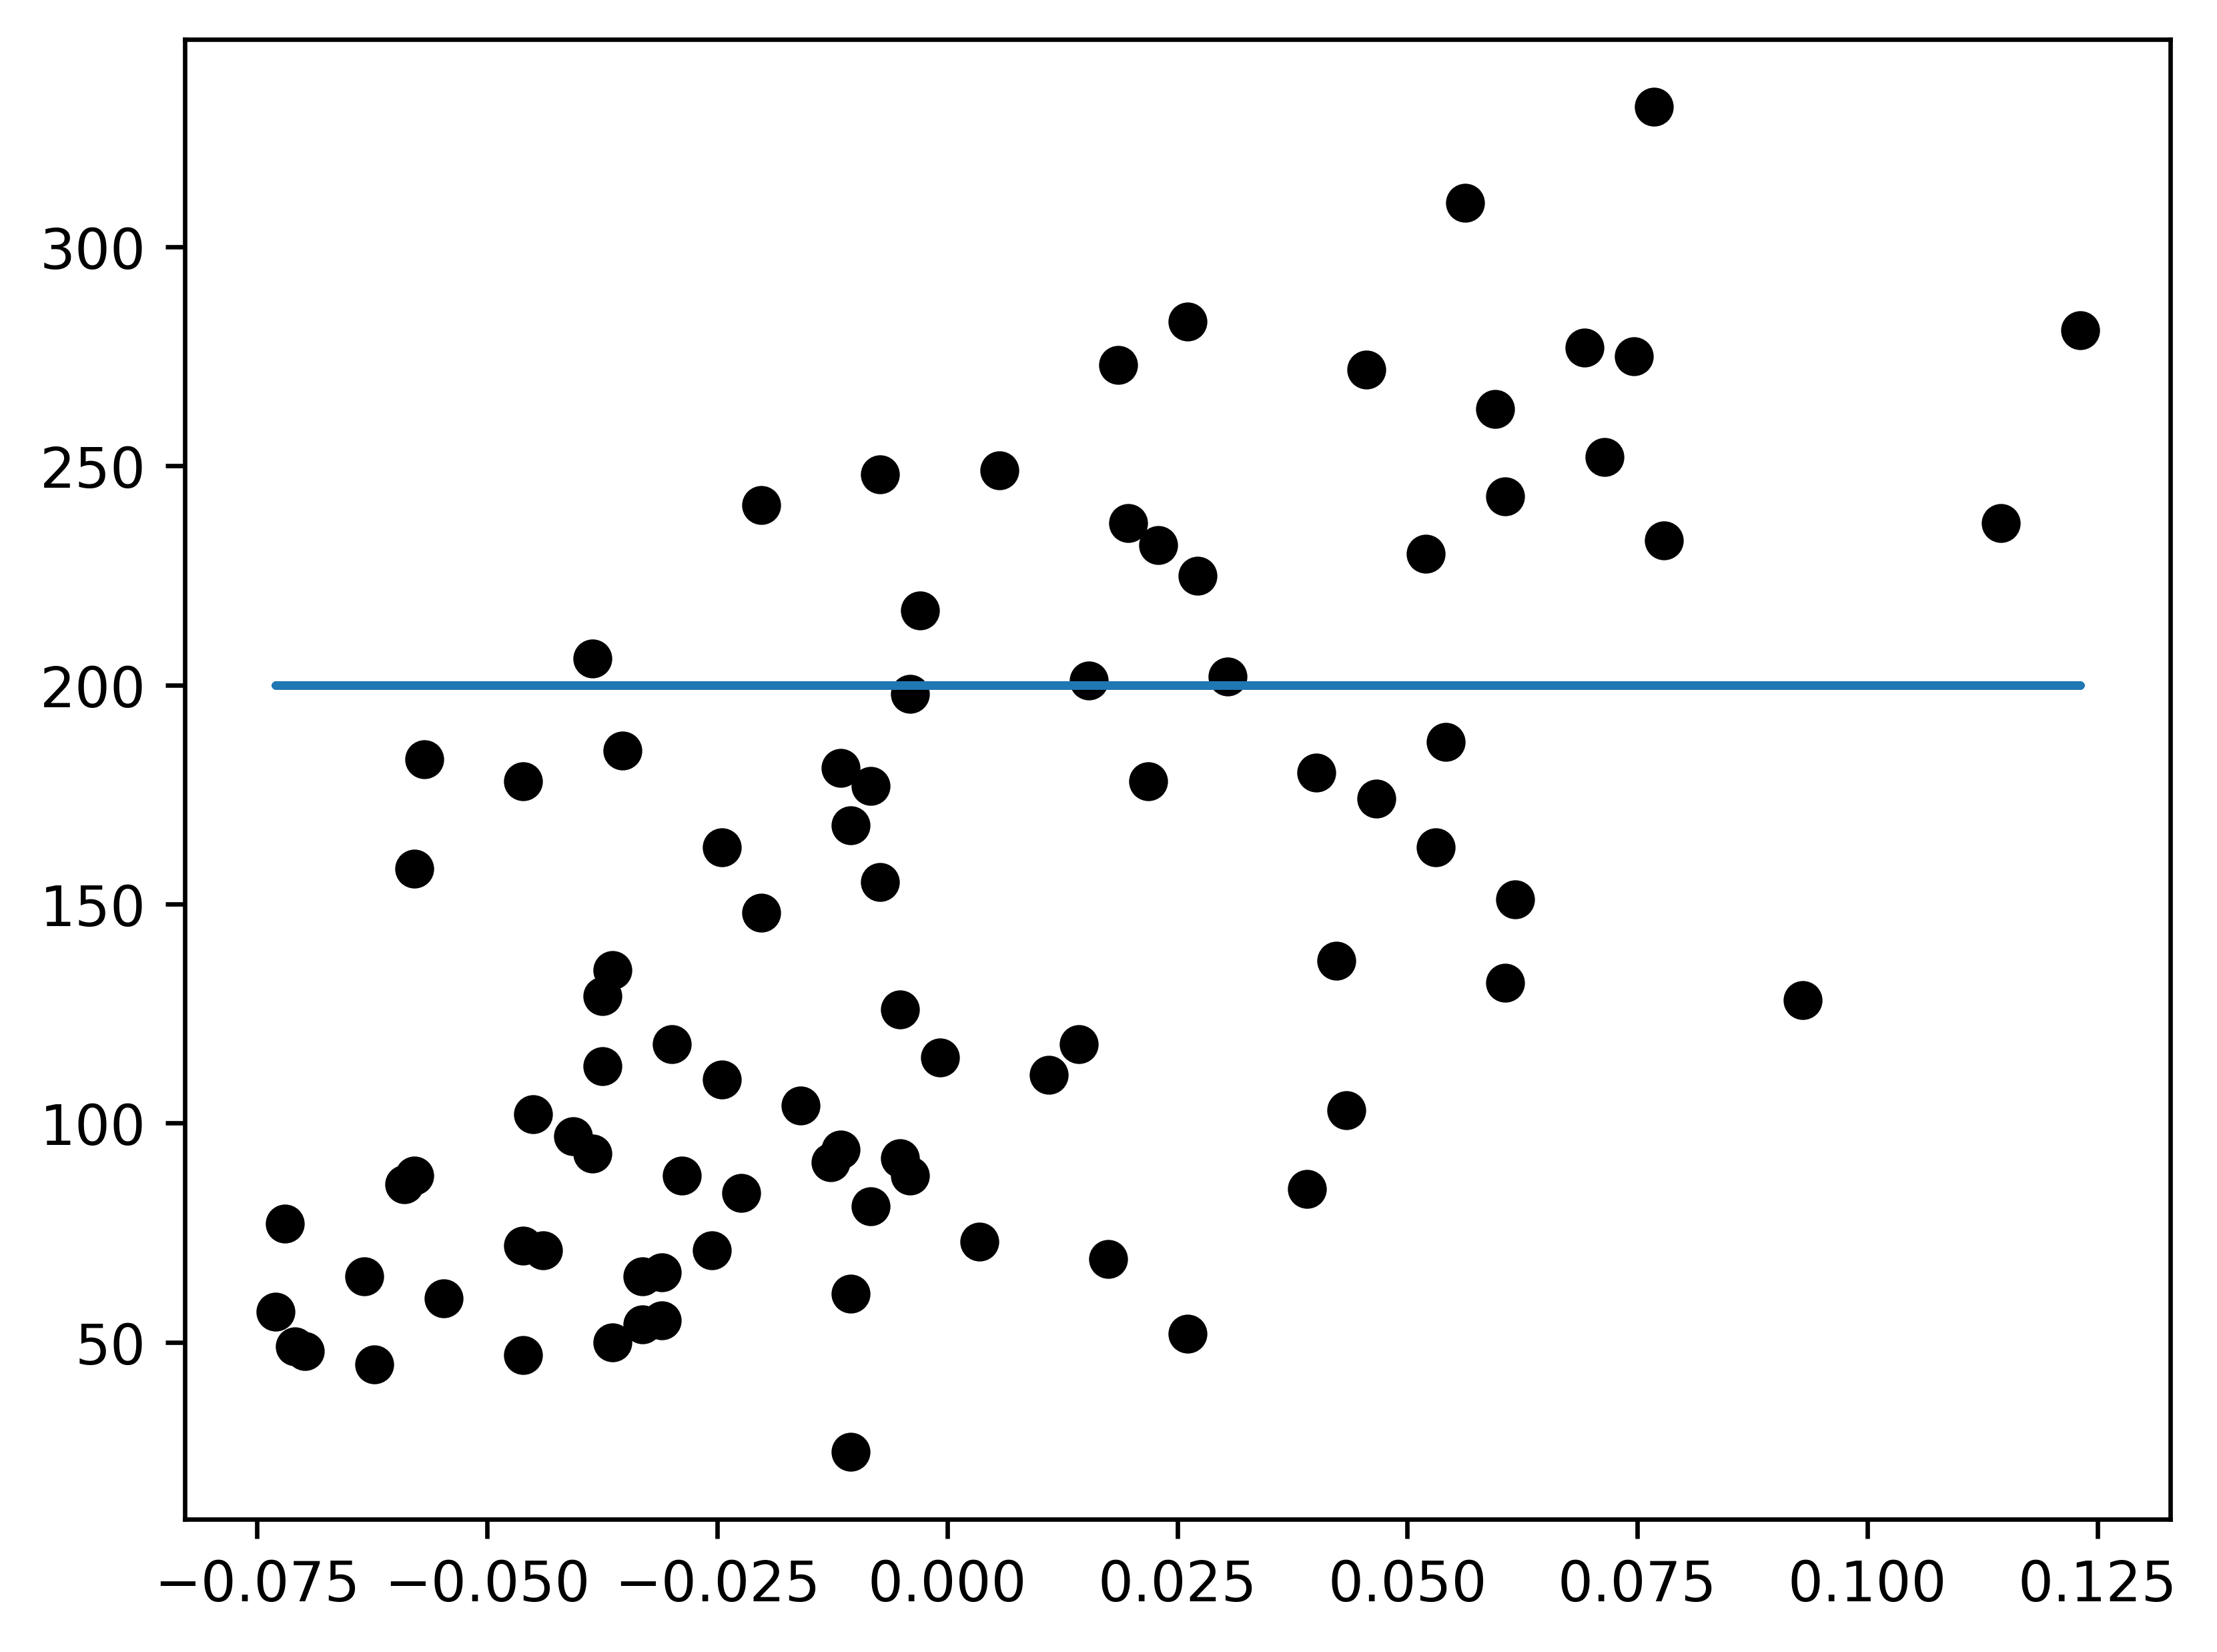

In [17]:
from sklearn import svm
clf = svm.SVC(kernel='linear')
clf.fit(train_features, train_target)
pred = clf.predict(test_features)

# Plot outputs
plt.scatter(test_features.bmi, test_target, color="black")
plt.plot(test_features.bmi, pred)

print(pred)


# print(data.feature_names)
# print(data.target)
# print(data.data[:5])

## Random Forest

### Reload data to make sure its clean

In [18]:
data = datasets.load_diabetes(as_frame=True)

diabetes_features = pd.DataFrame(data['data'])

diabetes_target = data['target']

train_features, test_features, train_target, test_target = train_test_split(diabetes_features, diabetes_target, test_size=.2, random_state=33)


In [19]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators = 10, random_state = 33)
rf.fit(train_features, train_target);

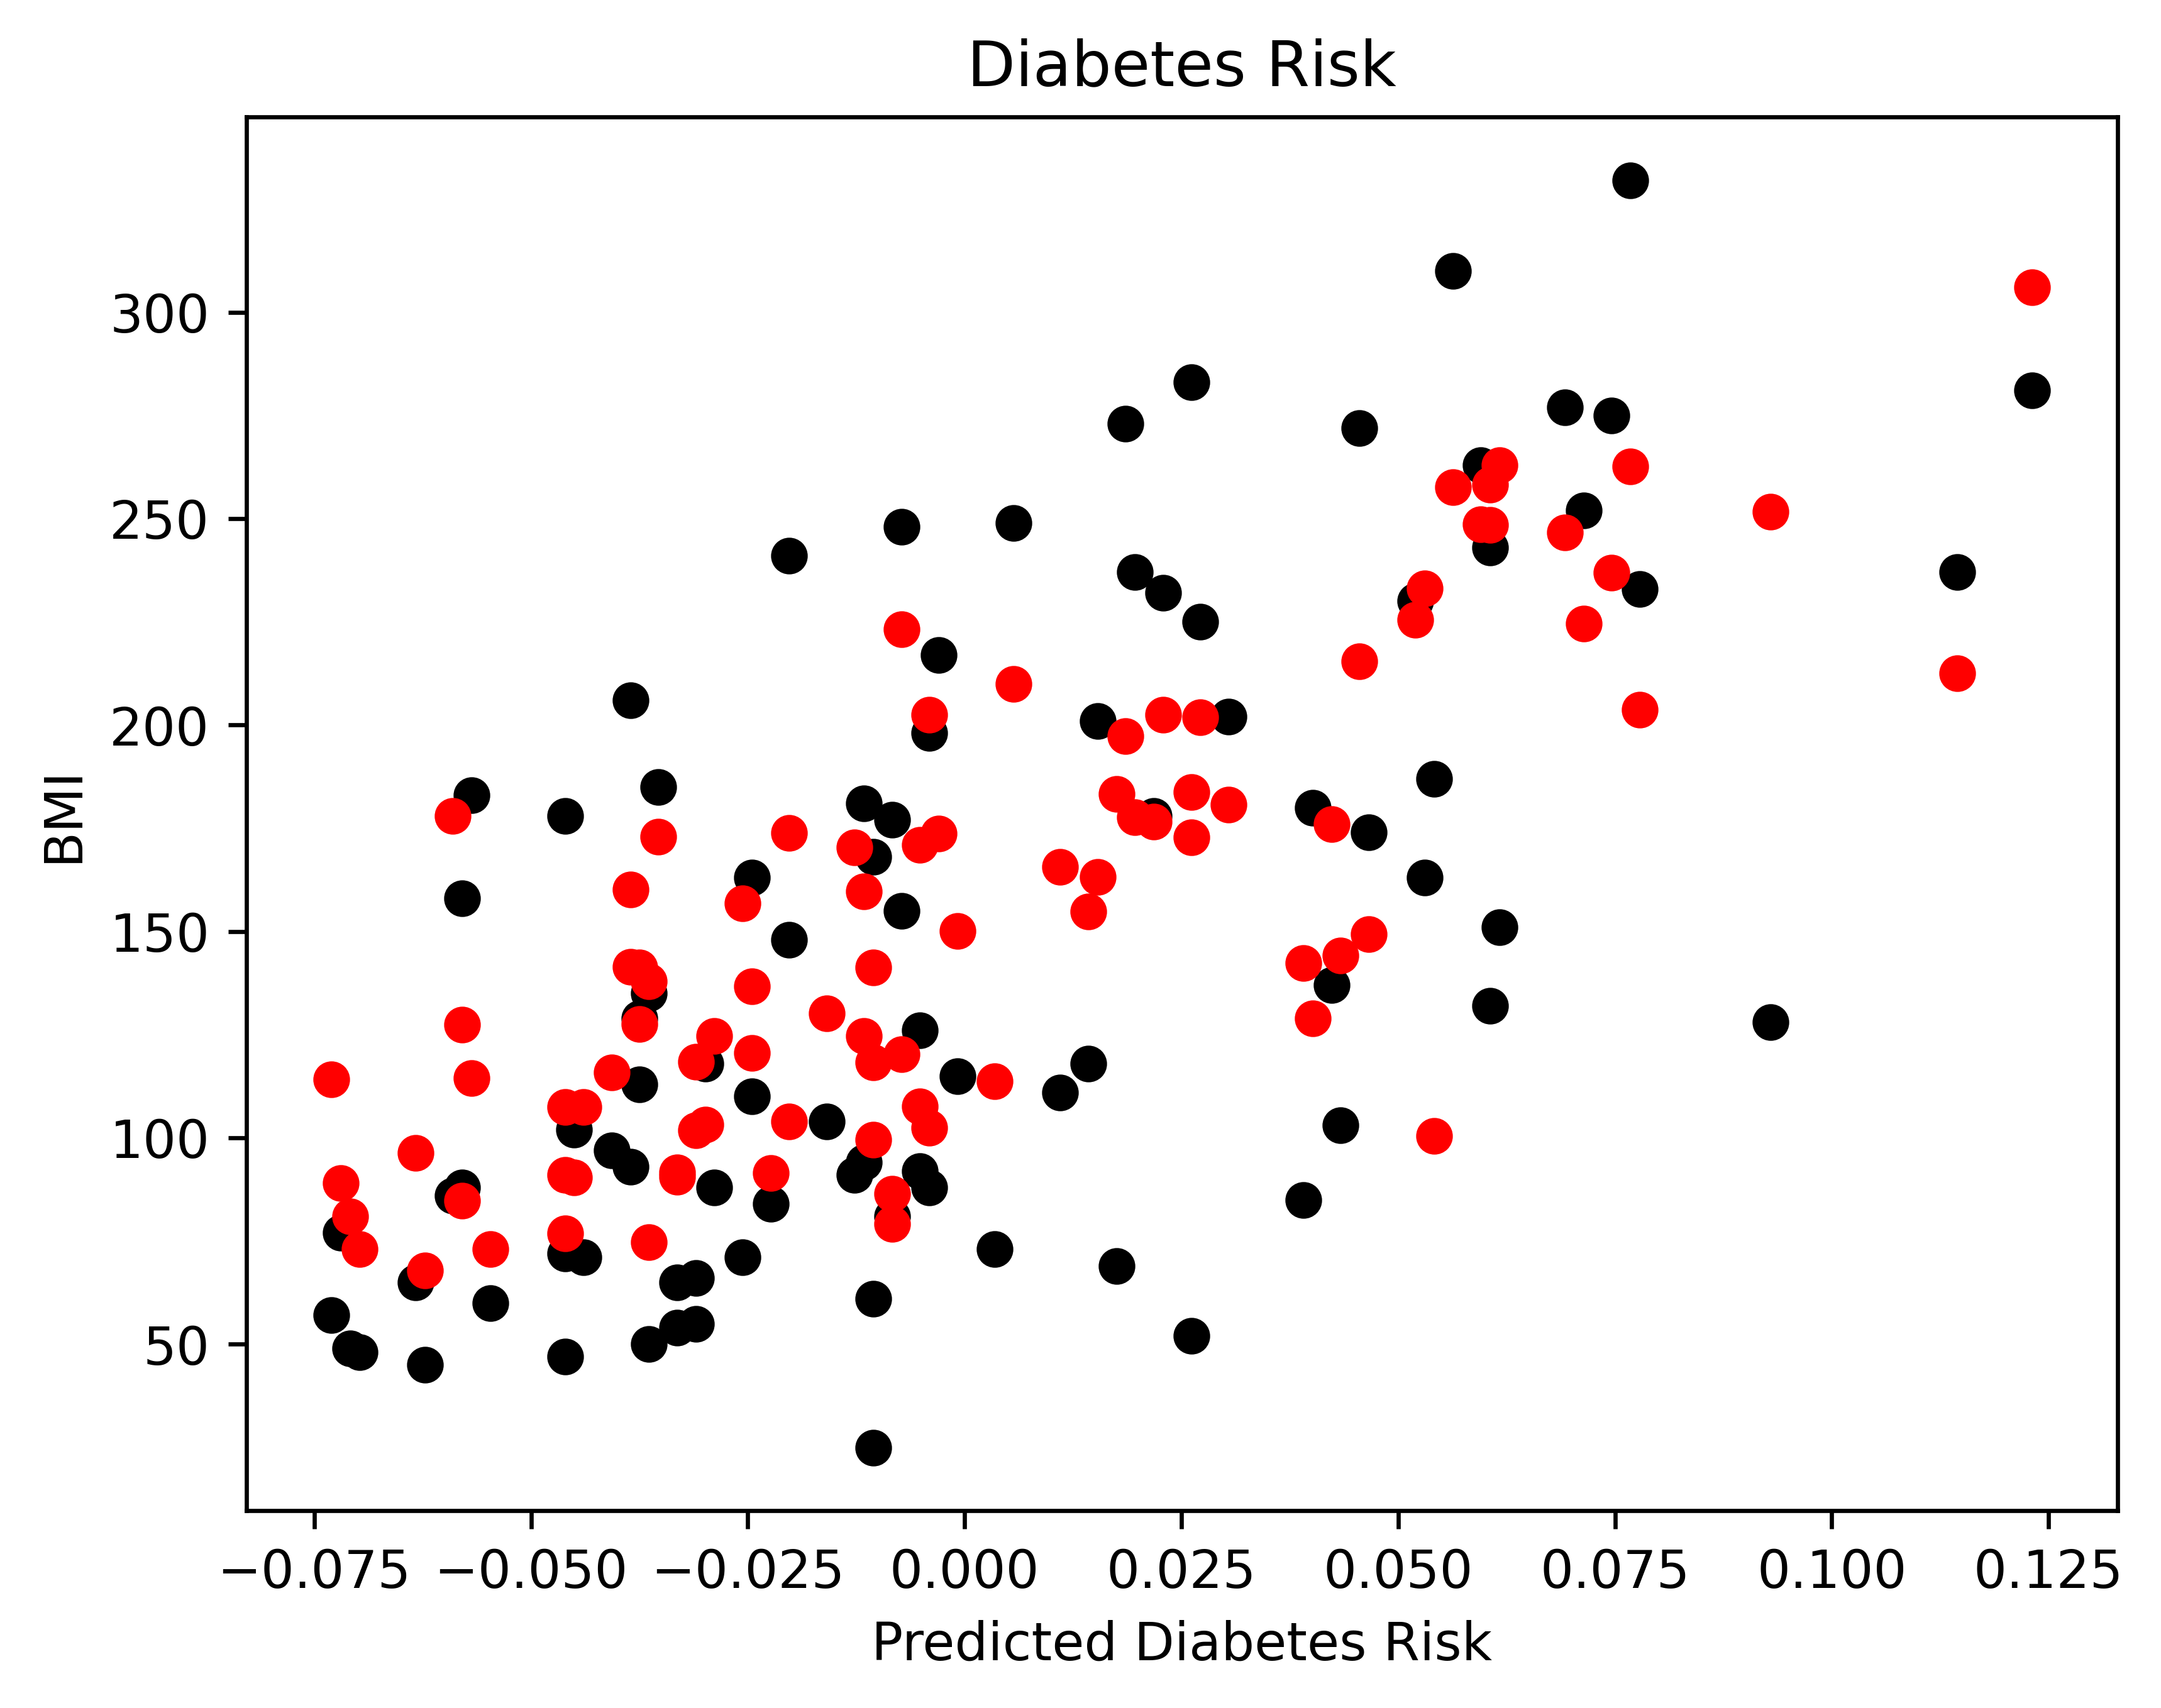

In [20]:
predictions = rf.predict(test_features)


plt.title('Diabetes Risk') 
plt.xlabel('Predicted Diabetes Risk') 
plt.ylabel('BMI') 

plt.scatter(test_features.bmi, test_target, color="black")
plt.scatter(test_features.bmi, predictions, color="red")

In [21]:
errors = abs(predictions - test_target)
print('Mean Absolute Error:', round(np.mean(errors), 2), 'units')

Mean Absolute Error: 44.76 units


In [22]:
data.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [23]:
from sklearn.tree import export_graphviz
import pydot
tree = rf.estimators_[5]
export_graphviz(tree, out_file = 'tree.dot', feature_names = data.feature_names, rounded = True, precision = 1)
(graph, ) = pydot.graph_from_dot_file('tree.dot')
graph.write_png('tree.png')

In [24]:
importances = list(rf.feature_importances_)

# List of tuples with variable and importance
feature_importances = [(feature, round(importance, 2)) for feature, importance in zip(data.feature_names, importances)]

feature_importances = sorted(feature_importances, key = lambda x: x[1], reverse = True)

feature_importances

[('bmi', 0.34),
 ('s5', 0.23),
 ('s6', 0.09),
 ('bp', 0.08),
 ('s3', 0.07),
 ('age', 0.06),
 ('s1', 0.06),
 ('s2', 0.06),
 ('sex', 0.01),
 ('s4', 0.01)]

# Classification

## Import Iris dataset

In [25]:
from sklearn import datasets 
import pandas as pd

iris = datasets.load_iris() 
features = iris.data[:, :2]
target = iris.target

pd_features = pd.DataFrame(features, columns = iris.feature_names[:2])

print(pd_features)

     sepal length (cm)  sepal width (cm)
0                  5.1               3.5
1                  4.9               3.0
2                  4.7               3.2
3                  4.6               3.1
4                  5.0               3.6
..                 ...               ...
145                6.7               3.0
146                6.3               2.5
147                6.5               3.0
148                6.2               3.4
149                5.9               3.0

[150 rows x 2 columns]


In [26]:
type(iris.target)

numpy.ndarray

In [27]:
pd_features['target'] = target
pd_features

,sepal length (cm),sepal width (cm),target
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0
...,...,...,...
145,6.7,3.0,2
146,6.3,2.5,2
147,6.5,3.0,2
148,6.2,3.4,2


In [28]:
class_0 = pd_features.query('target==0')
class_1 = pd_features.query('target==1')
class_2 = pd_features.query('target==2')

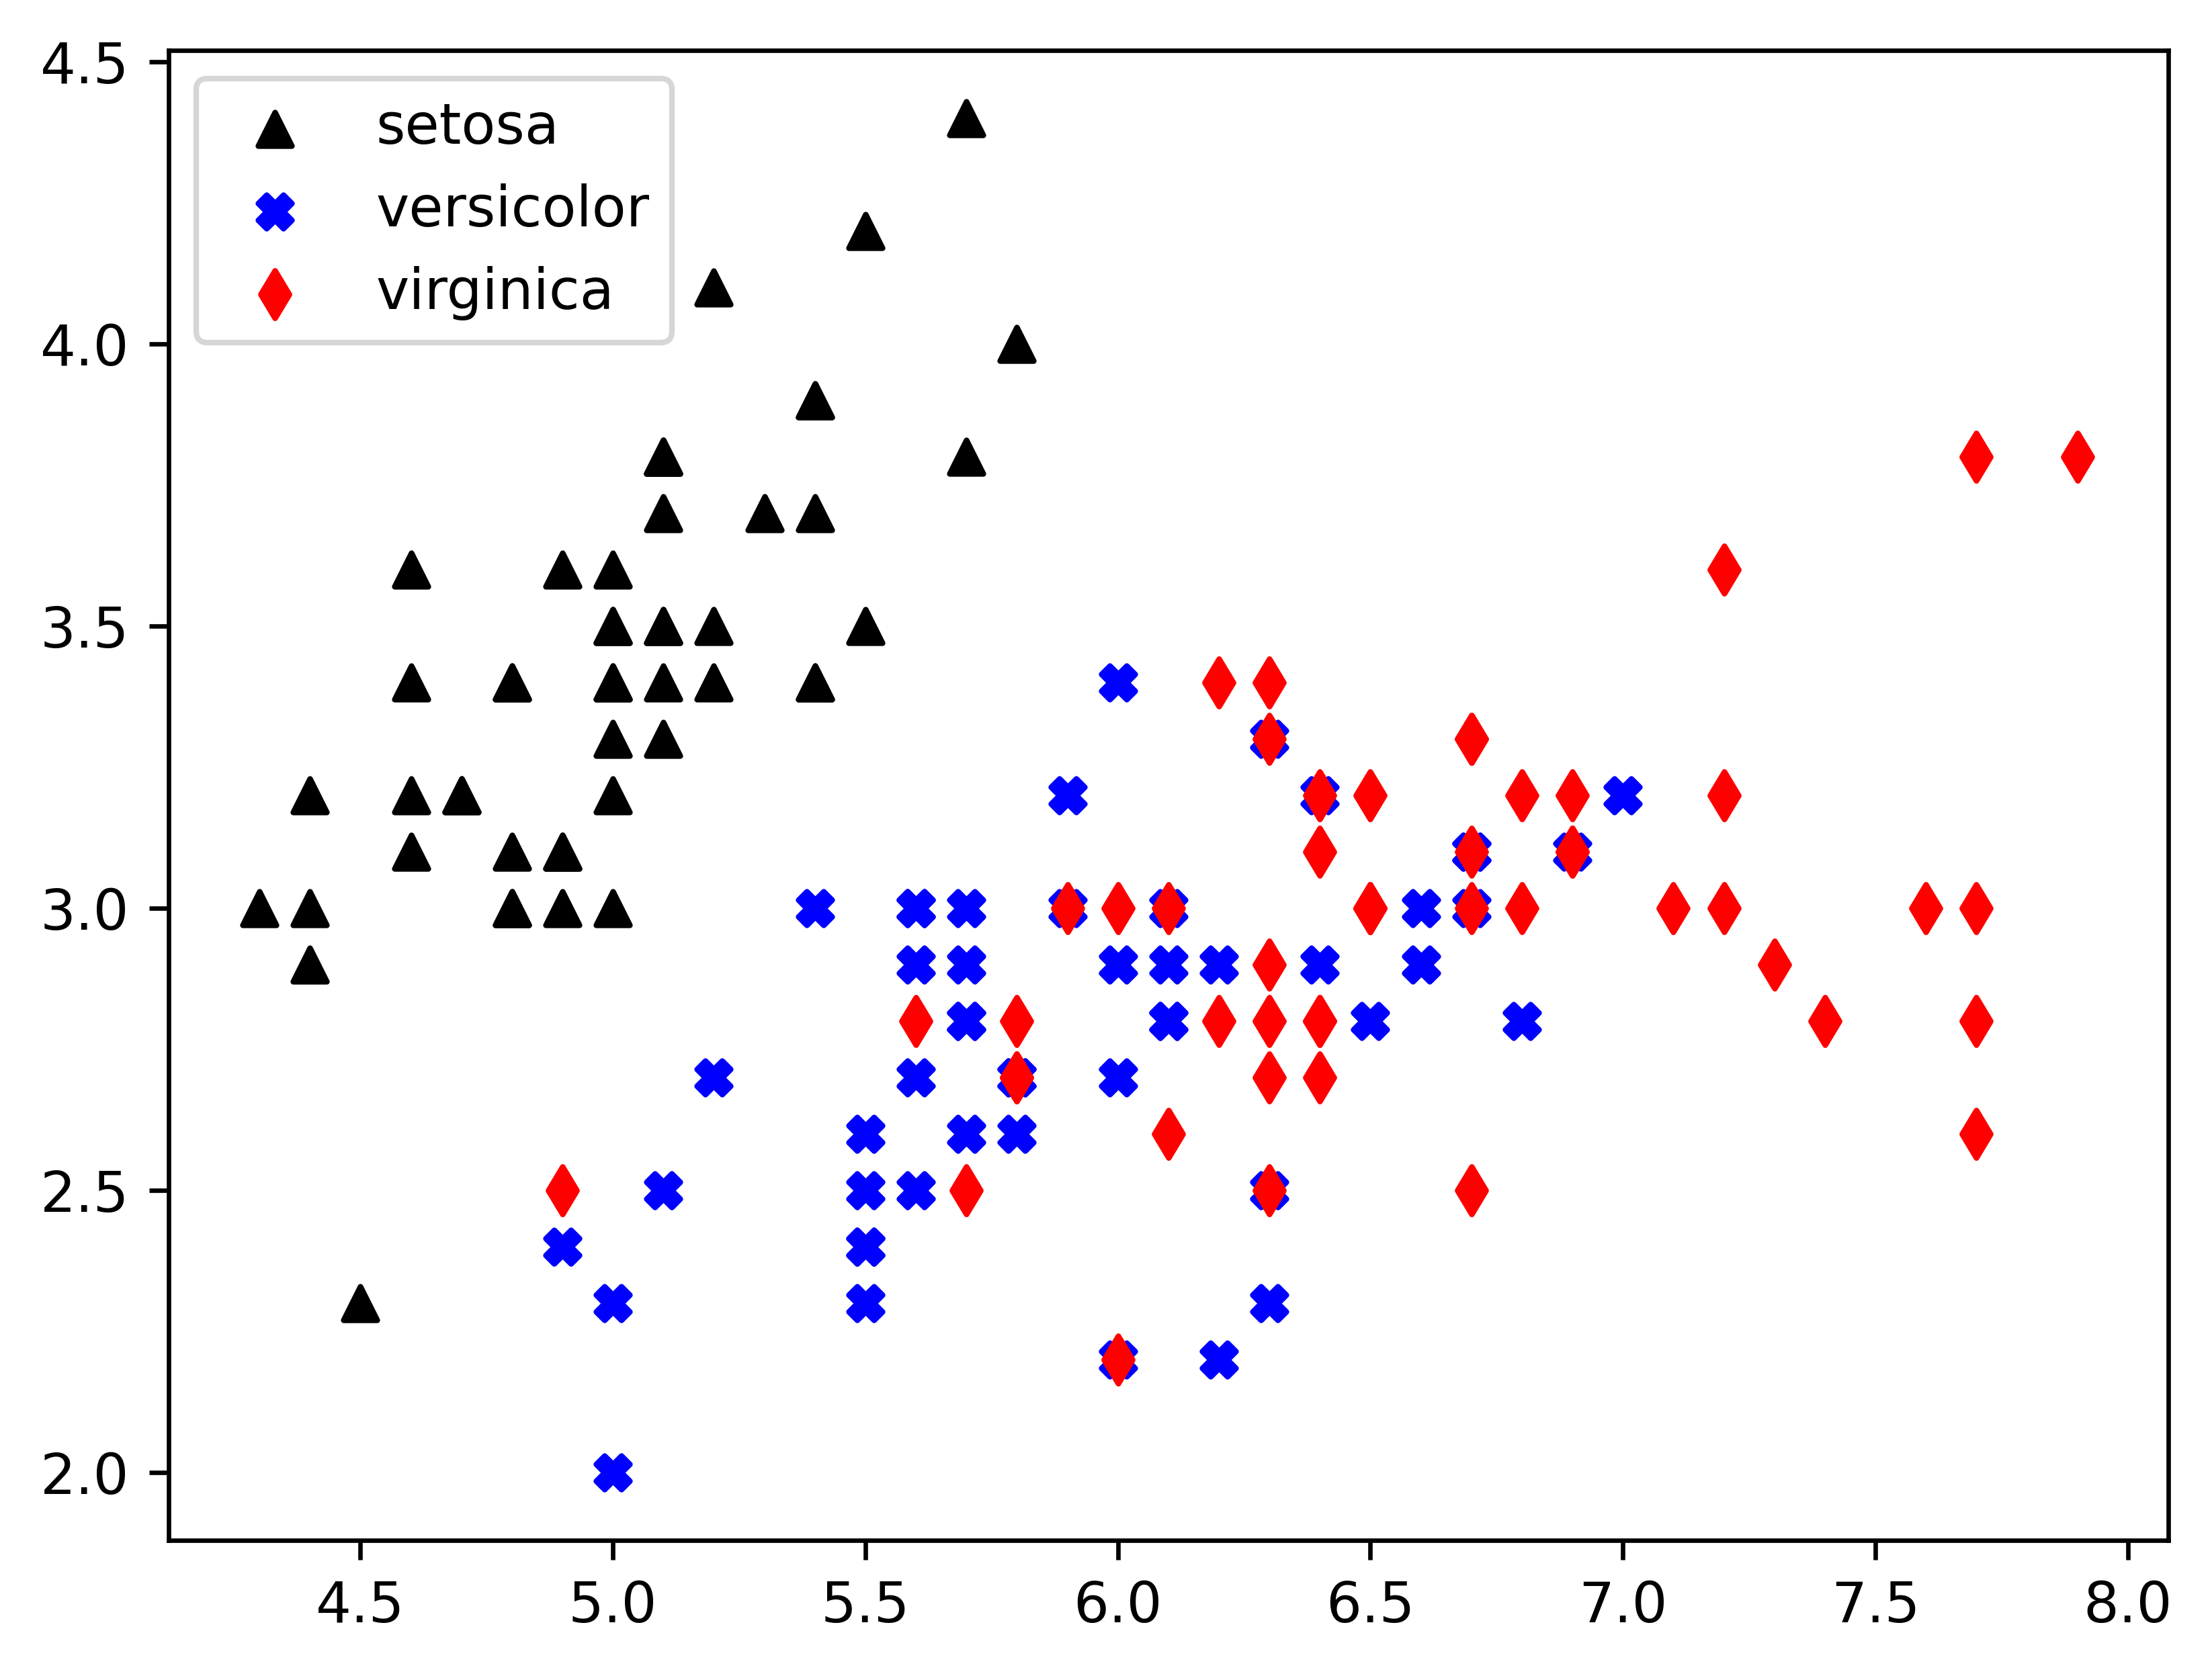

In [29]:
import matplotlib.pyplot as plt
plt.scatter(class_0.iloc[:,0], class_0.iloc[:,1], marker="^", color="black", label="setosa")
plt.scatter(class_1.iloc[:,0], class_1.iloc[:,1], marker="X",  color="blue", label="versicolor")
plt.scatter(class_2.iloc[:,0], class_2.iloc[:,1], marker="d",color="red", label="virginica")
plt.legend(loc="upper left")
plt.show()

In [30]:
pd_features

,sepal length (cm),sepal width (cm),target
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0
...,...,...,...
145,6.7,3.0,2
146,6.3,2.5,2
147,6.5,3.0,2
148,6.2,3.4,2


## Logistic Regression

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(pd_features.iloc[:,:2], target, test_size = 0.25, random_state = 33)

In [32]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression().fit(X_train,y_train)

In [33]:
predictions = classifier.predict(X_test)

X_test['target'] = predictions
X_test

,sepal length (cm),sepal width (cm),target
96,5.7,2.9,1
65,6.7,3.1,2
29,4.7,3.2,0
54,6.5,2.8,2
134,6.1,2.6,1
100,6.3,3.3,2
24,4.8,3.4,0
17,5.1,3.5,0
137,6.4,3.1,2
120,6.9,3.2,2


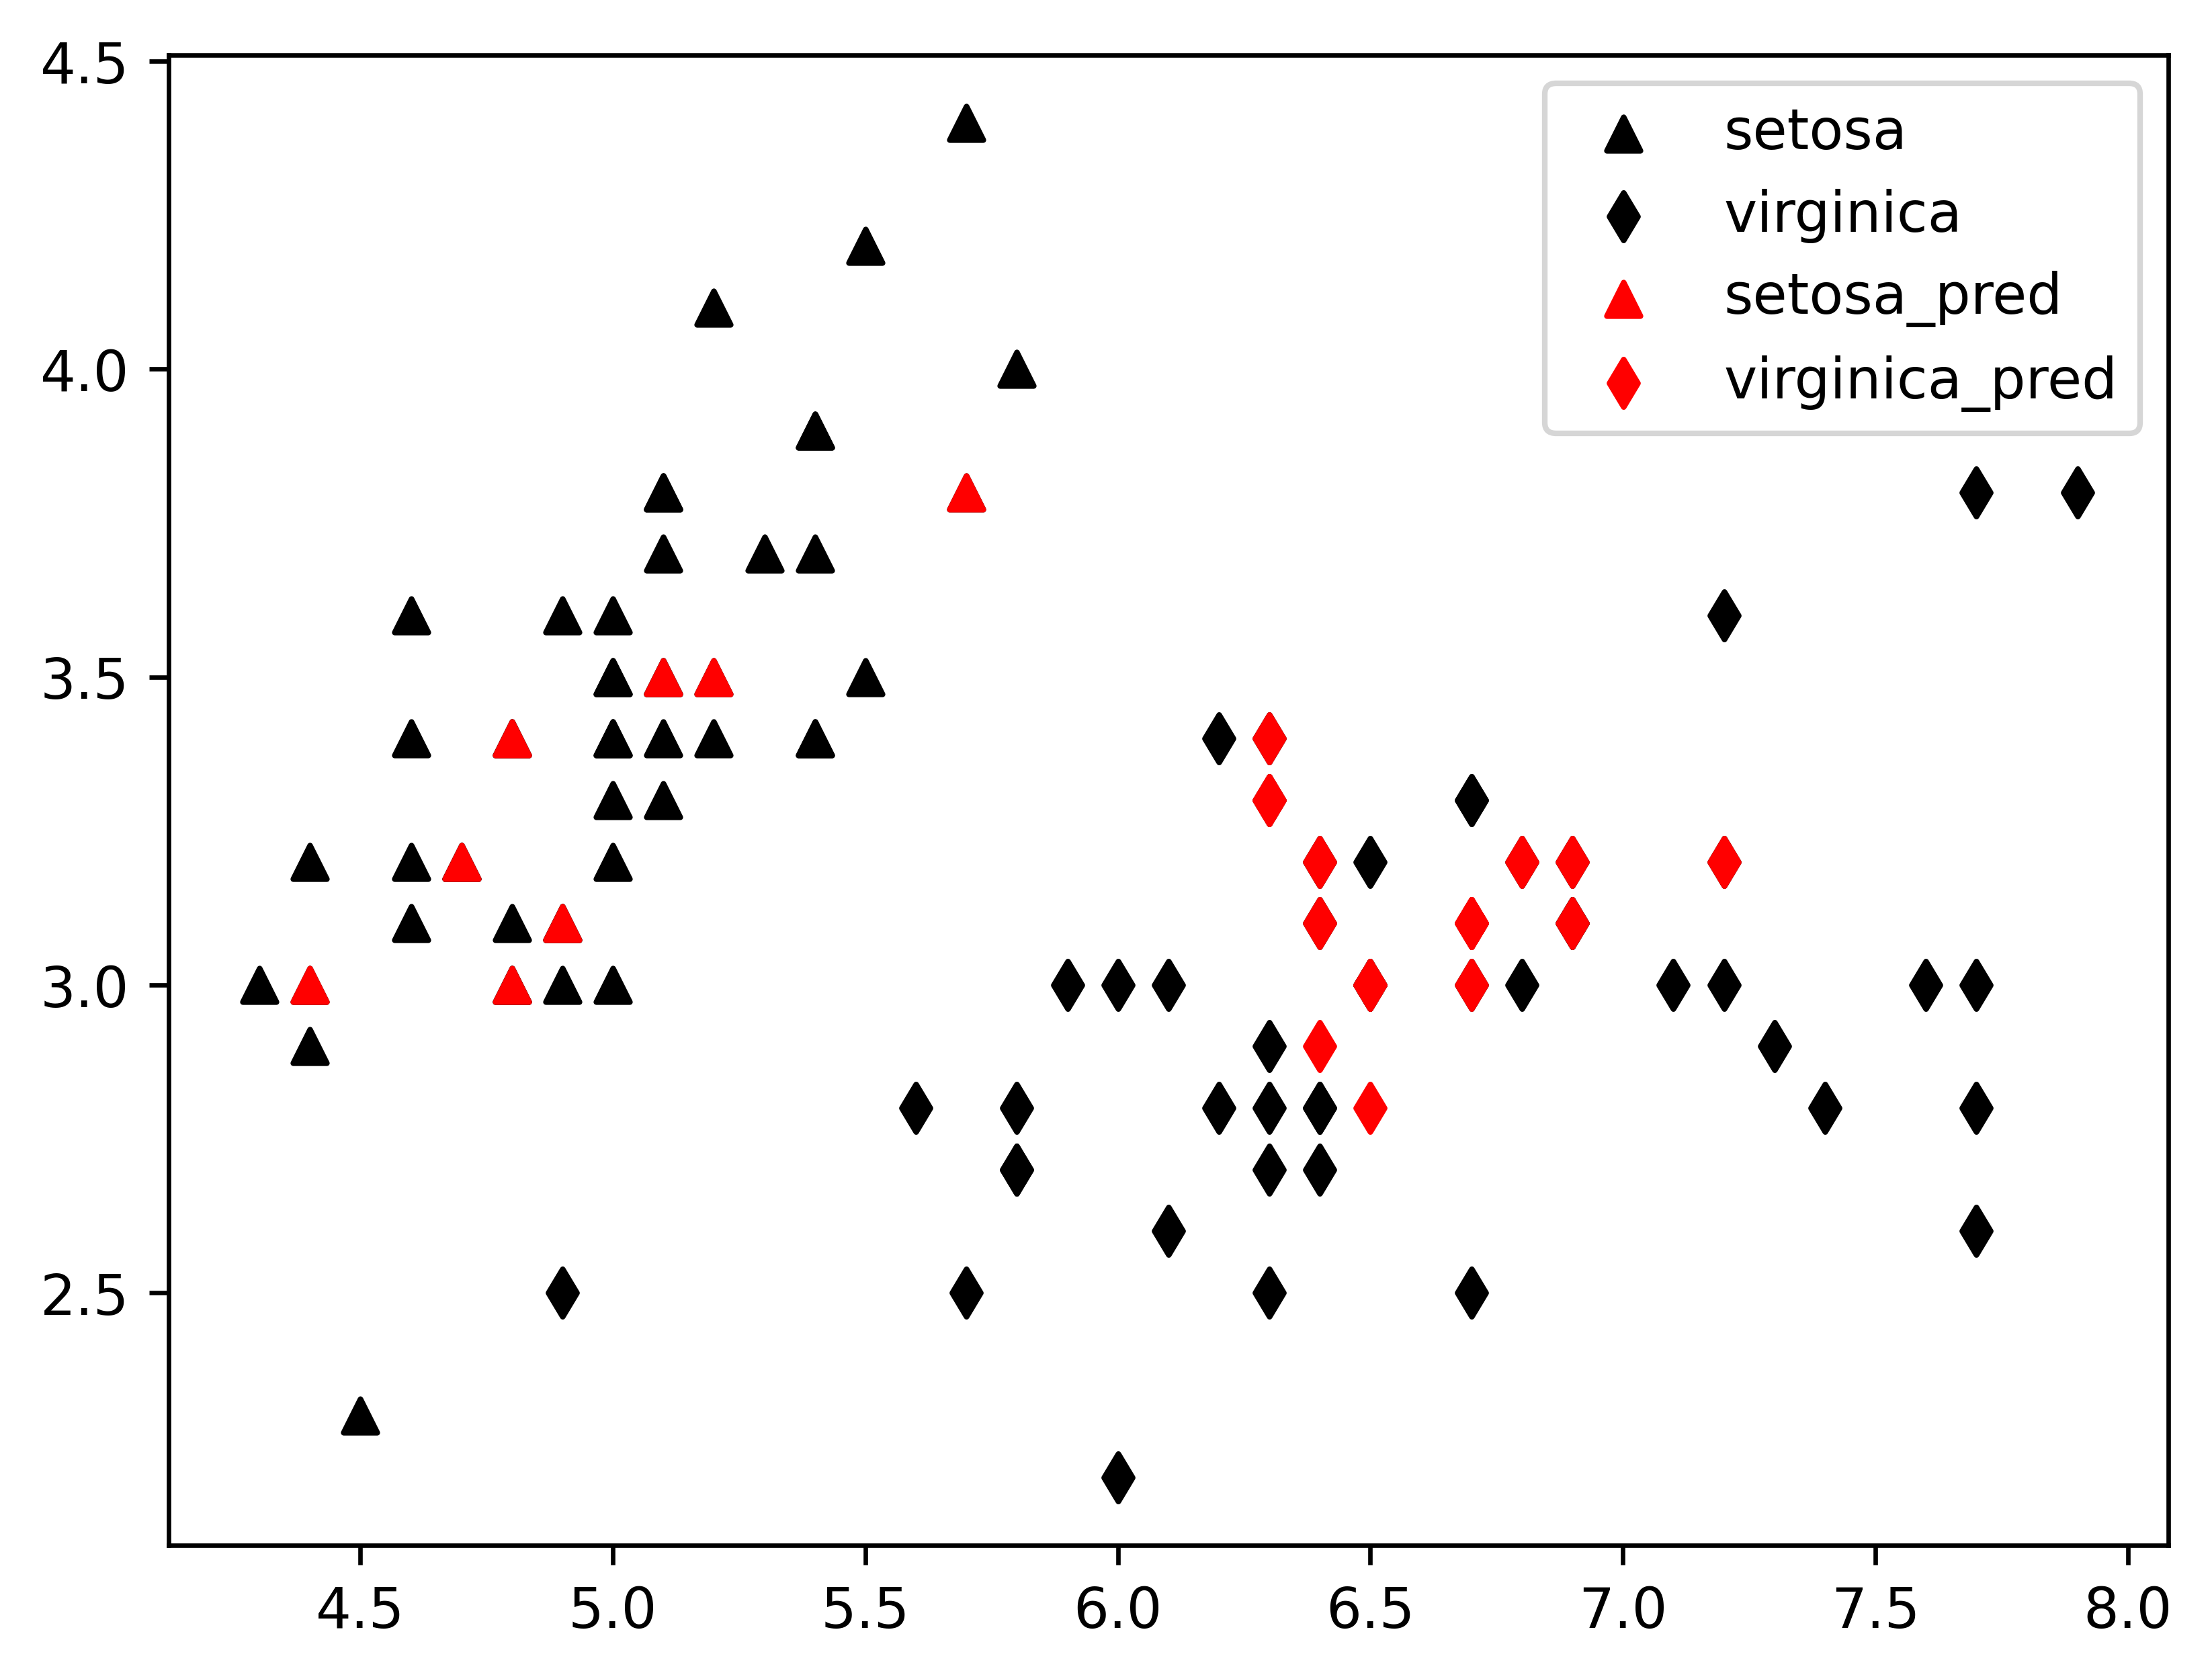

In [34]:
import matplotlib.pyplot as plt

pred_class_0 = X_test.query('target==0')
pred_class_2 = X_test.query('target==2')

plt.scatter(class_0.iloc[:,0], class_0.iloc[:,1], marker="^", color="black", label="setosa")
plt.scatter(class_2.iloc[:,0], class_2.iloc[:,1], marker="d",color="black", label="virginica")

plt.scatter(pred_class_0.iloc[:,0], pred_class_0.iloc[:,1], marker="^", color="red", label="setosa_pred")
plt.scatter(pred_class_2.iloc[:,0], pred_class_2.iloc[:,1], marker="d",color="red", label="virginica_pred")


plt.legend()
plt.show()

## One Class SVM (Anomaly detection/Outlier detection)

### Create toy dataset

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager
from sklearn import svm

X = 0.2 * np.random.randn(50, 2)
X_train = np.r_[X + 3]
# Generate some regular novel observations
X = 0.2 * np.random.randn(20, 2)
X_test = np.r_[X + 3]
# Generate some abnormal novel observations
X_outliers = np.random.uniform(low=-5, high=5, size=(20, 2))

In [36]:
from sklearn import svm

one_svm = svm.OneClassSVM(nu=0.1, kernel="rbf", gamma=0.1)
one_svm.fit(X_train)

OneClassSVM(gamma=0.1, nu=0.1)

In [37]:
y_pred_train = one_svm.predict(X_train)
y_pred_test = one_svm.predict(X_test)
y_pred_outliers = one_svm.predict(X_outliers)
print(y_pred_train[y_pred_train == -1].size)
print(y_pred_test[y_pred_test == -1].size)
print(y_pred_outliers[y_pred_outliers == 1].size)

4
1
0


### Plot one-class SVM

In [38]:
X_outliers

array([[-3.88023107e+00, -1.09242334e+00],
       [-2.21299797e+00,  2.68343843e+00],
       [ 4.46476190e+00,  1.13355023e+00],
       [ 4.13788320e+00, -4.30364837e+00],
       [-2.31681893e-01,  3.68531026e+00],
       [-4.85151124e+00, -3.24065928e-01],
       [-3.72274490e+00,  4.82111841e+00],
       [ 2.78416162e+00,  6.93672927e-01],
       [-1.78080077e+00, -4.43370194e-03],
       [-4.30942052e+00, -1.59389887e+00],
       [-1.09057779e+00, -6.86014828e-02],
       [ 1.67802804e+00,  3.94629784e+00],
       [-1.68071214e+00,  7.33330653e-01],
       [ 7.41933087e-01, -5.55137084e-01],
       [-1.75951617e+00, -7.92918448e-01],
       [-2.61311487e+00, -1.23473396e+00],
       [-4.22936753e+00,  4.51174627e+00],
       [ 3.86152171e+00,  4.51783789e+00],
       [ 2.57377917e+00,  4.32475949e+00],
       [-7.87245200e-02,  1.80509377e+00]])

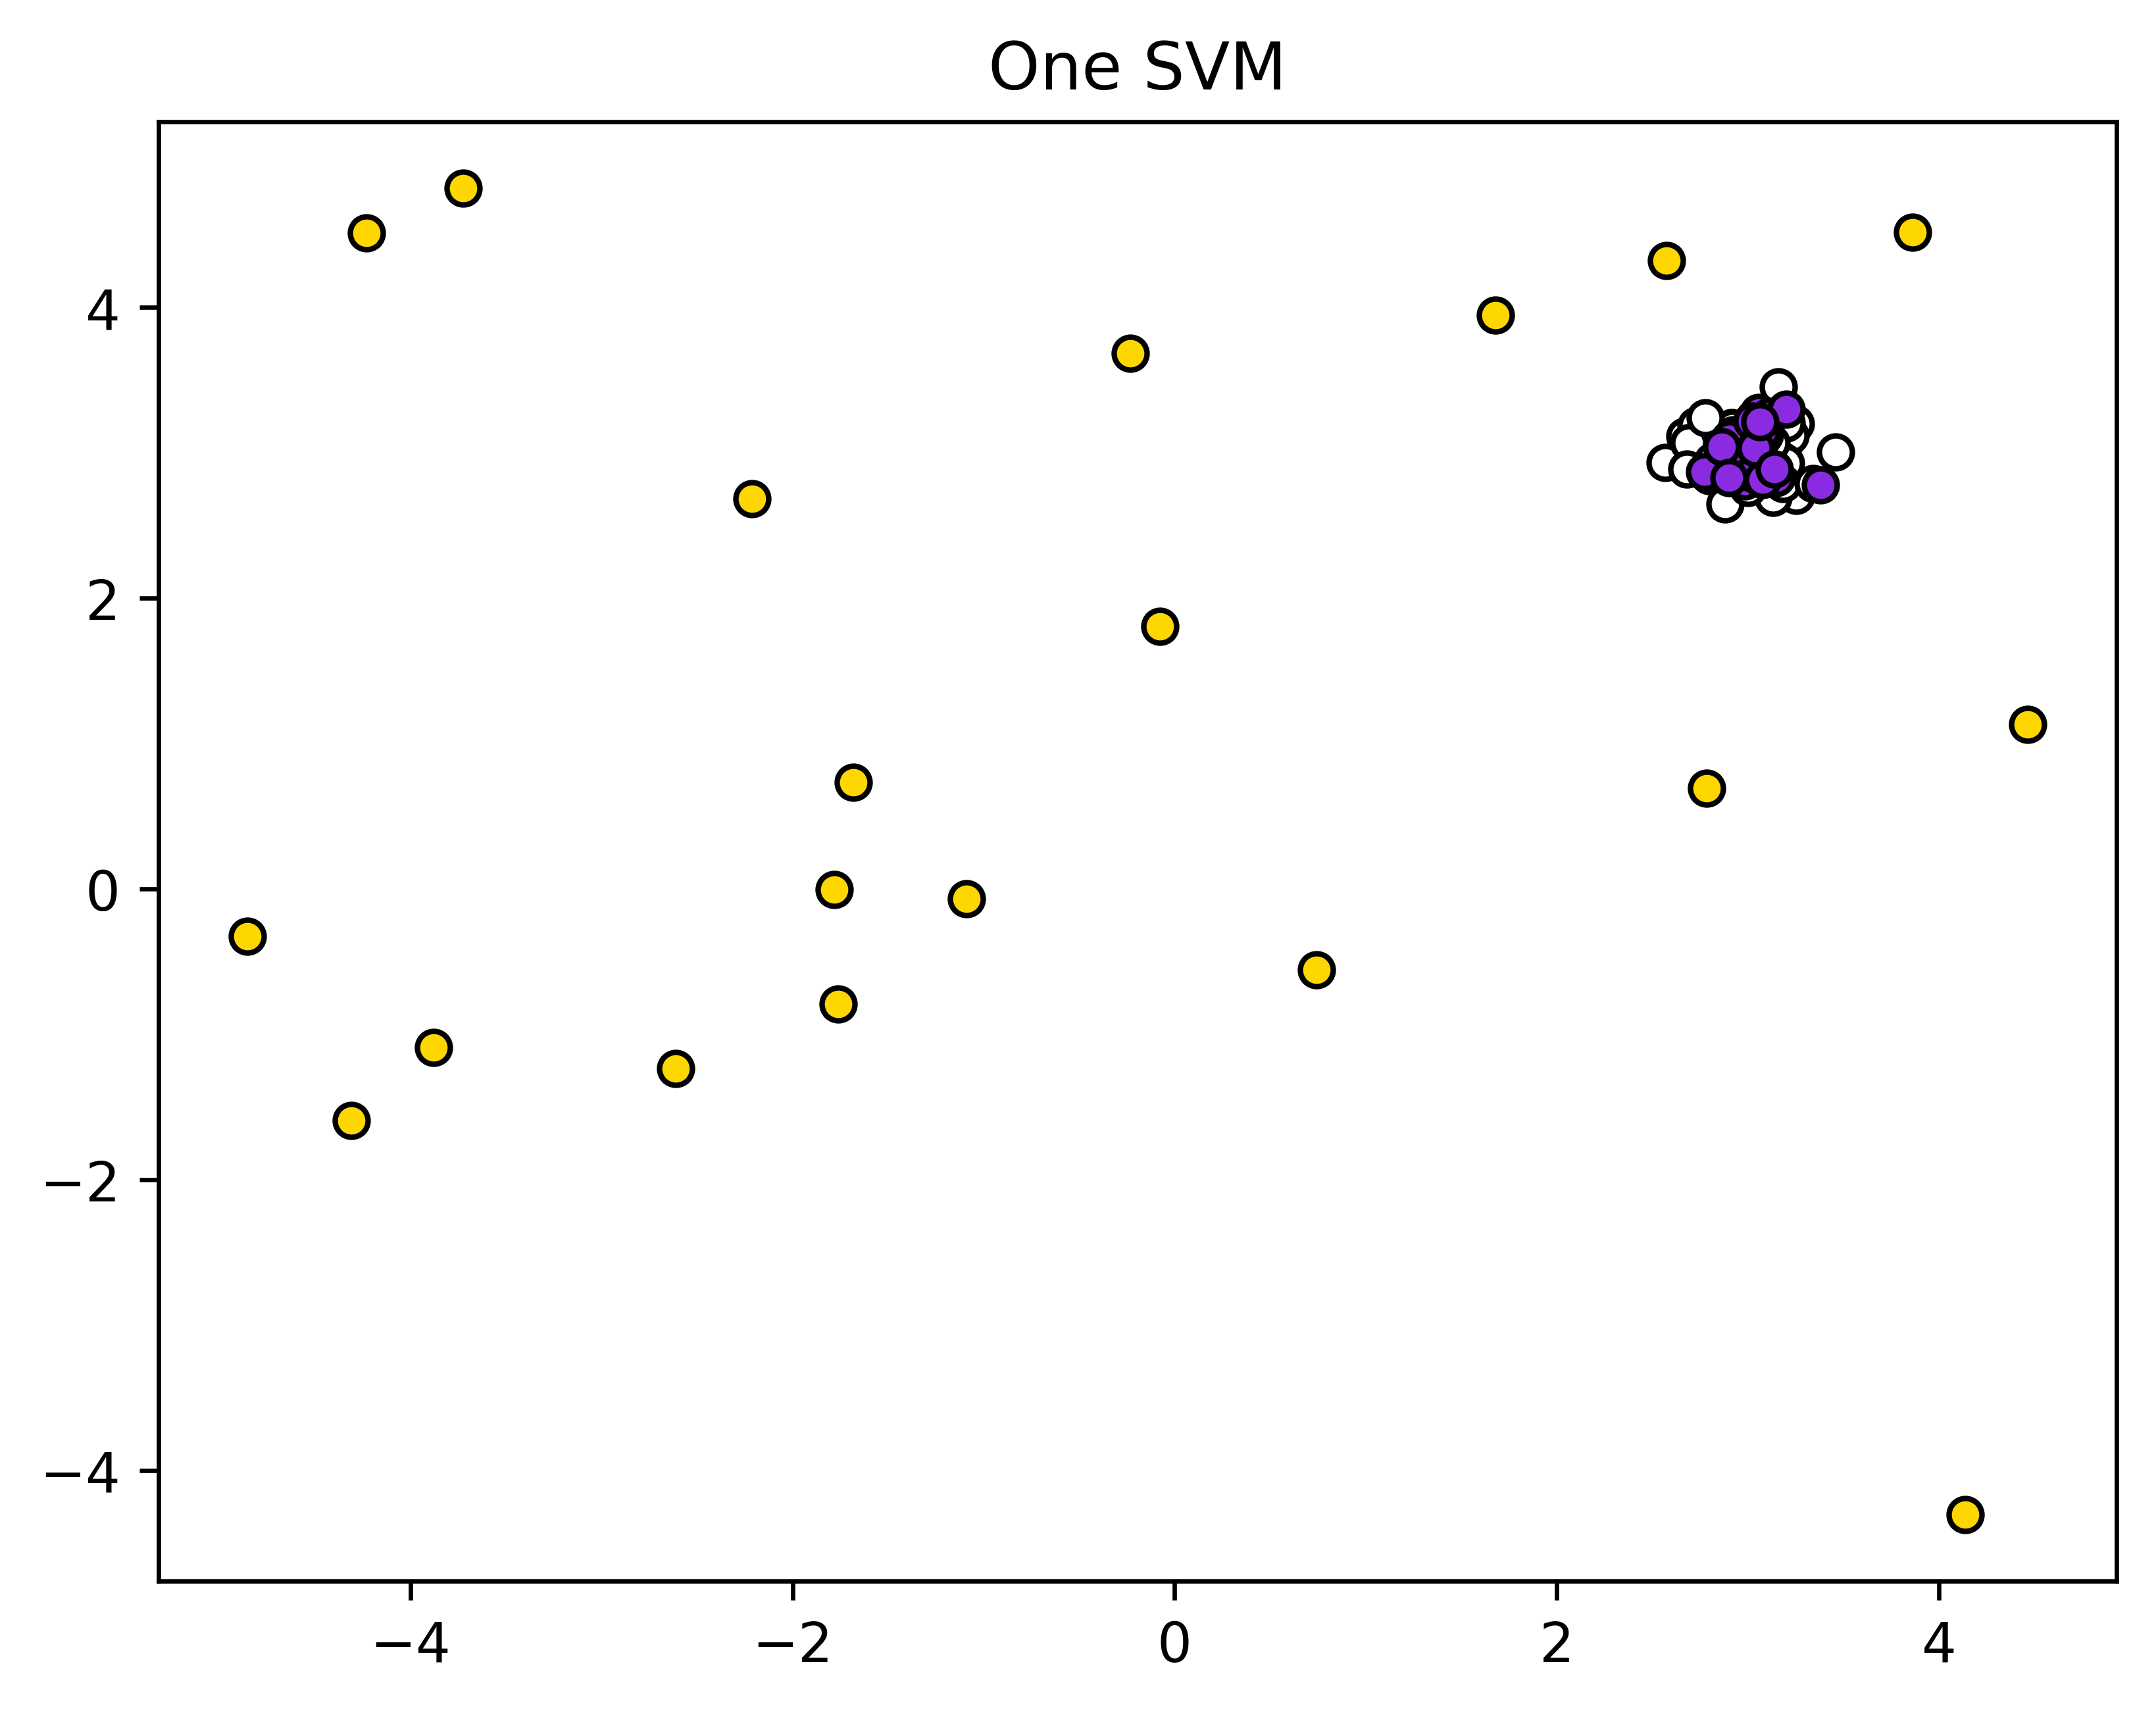

In [39]:
import matplotlib.pyplot as plt

plt.title("One SVM")


plt.scatter(X_train[:, 0], X_train[:, 1], c="white",  edgecolors="k",label="X Train")
plt.scatter(X_test[:, 0], X_test[:, 1], c="blueviolet",  edgecolors="k",label="X Test")
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c="gold", edgecolors="k",label="X Outliers")

# plt.legend()

In [40]:
print(X_outliers.shape)
print(y_pred_outliers.shape)

(20, 2)
(20,)


In [41]:
# np.delete(X_outliers,[:2],0)

In [42]:
X_outliers = np.column_stack((X_outliers, y_pred_outliers))
X_outliers

array([[-3.88023107e+00, -1.09242334e+00, -1.00000000e+00],
       [-2.21299797e+00,  2.68343843e+00, -1.00000000e+00],
       [ 4.46476190e+00,  1.13355023e+00, -1.00000000e+00],
       [ 4.13788320e+00, -4.30364837e+00, -1.00000000e+00],
       [-2.31681893e-01,  3.68531026e+00, -1.00000000e+00],
       [-4.85151124e+00, -3.24065928e-01, -1.00000000e+00],
       [-3.72274490e+00,  4.82111841e+00, -1.00000000e+00],
       [ 2.78416162e+00,  6.93672927e-01, -1.00000000e+00],
       [-1.78080077e+00, -4.43370194e-03, -1.00000000e+00],
       [-4.30942052e+00, -1.59389887e+00, -1.00000000e+00],
       [-1.09057779e+00, -6.86014828e-02, -1.00000000e+00],
       [ 1.67802804e+00,  3.94629784e+00, -1.00000000e+00],
       [-1.68071214e+00,  7.33330653e-01, -1.00000000e+00],
       [ 7.41933087e-01, -5.55137084e-01, -1.00000000e+00],
       [-1.75951617e+00, -7.92918448e-01, -1.00000000e+00],
       [-2.61311487e+00, -1.23473396e+00, -1.00000000e+00],
       [-4.22936753e+00,  4.51174627e+00

In [43]:
df = pd.DataFrame(X_outliers, columns= ['x','y','anomaly_value'])
df

,x,y,anomaly_value
0,-3.880231,-1.092423,-1.0
1,-2.212998,2.683438,-1.0
2,4.464762,1.133550,-1.0
3,4.137883,-4.303648,-1.0
4,-0.231682,3.685310,-1.0
5,-4.851511,-0.324066,-1.0
6,-3.722745,4.821118,-1.0
7,2.784162,0.693673,-1.0
8,-1.780801,-0.004434,-1.0
9,-4.309421,-1.593899,-1.0


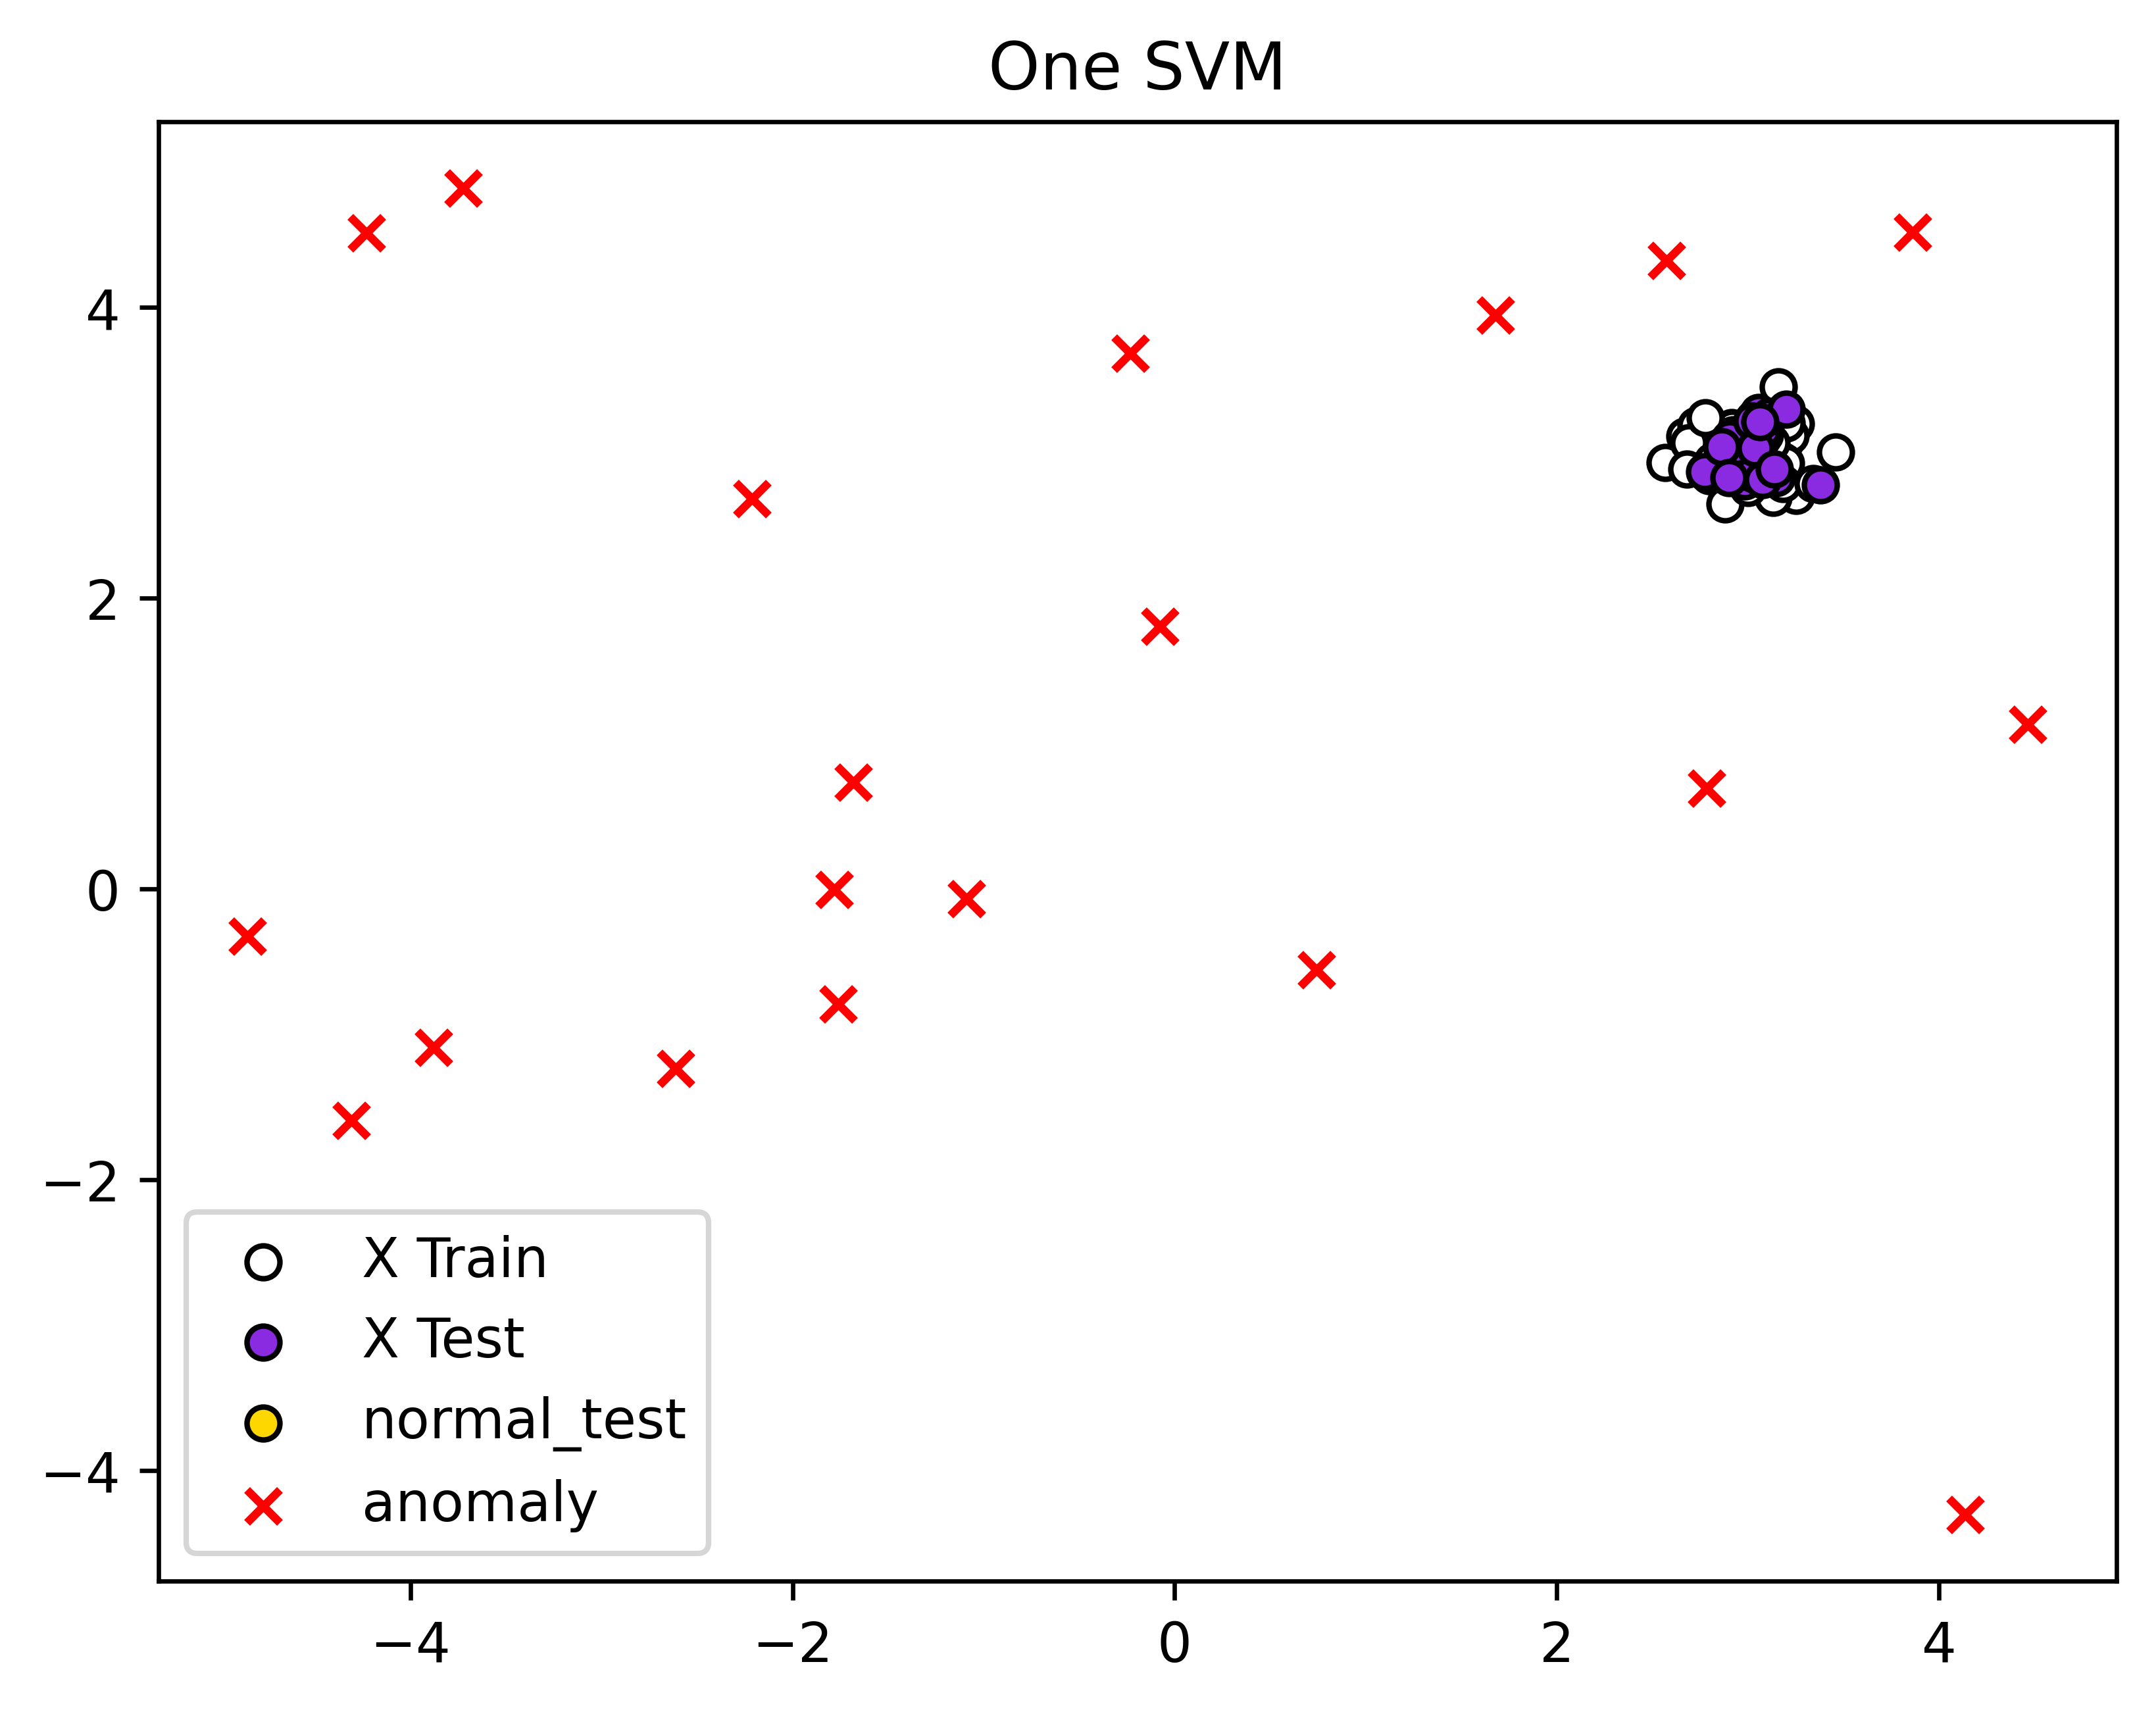

In [44]:
valid = df.query('anomaly_value == 1')
anomaly = df.query('anomaly_value == -1')

plt.title("One SVM")

plt.scatter(X_train[:, 0], X_train[:, 1], c="white",  edgecolors="k", label="X Train")
plt.scatter(X_test[:, 0], X_test[:, 1], c="blueviolet",  edgecolors="k", label="X Test")
plt.scatter(valid.iloc[:, 0], valid.iloc[:, 1], c="gold", edgecolors="k", label="normal_test")
plt.scatter(anomaly.iloc[:, 0], anomaly.iloc[:,  1], marker="x",color="red", label="anomaly")

plt.legend()
plt.show()

## Isolation Forests

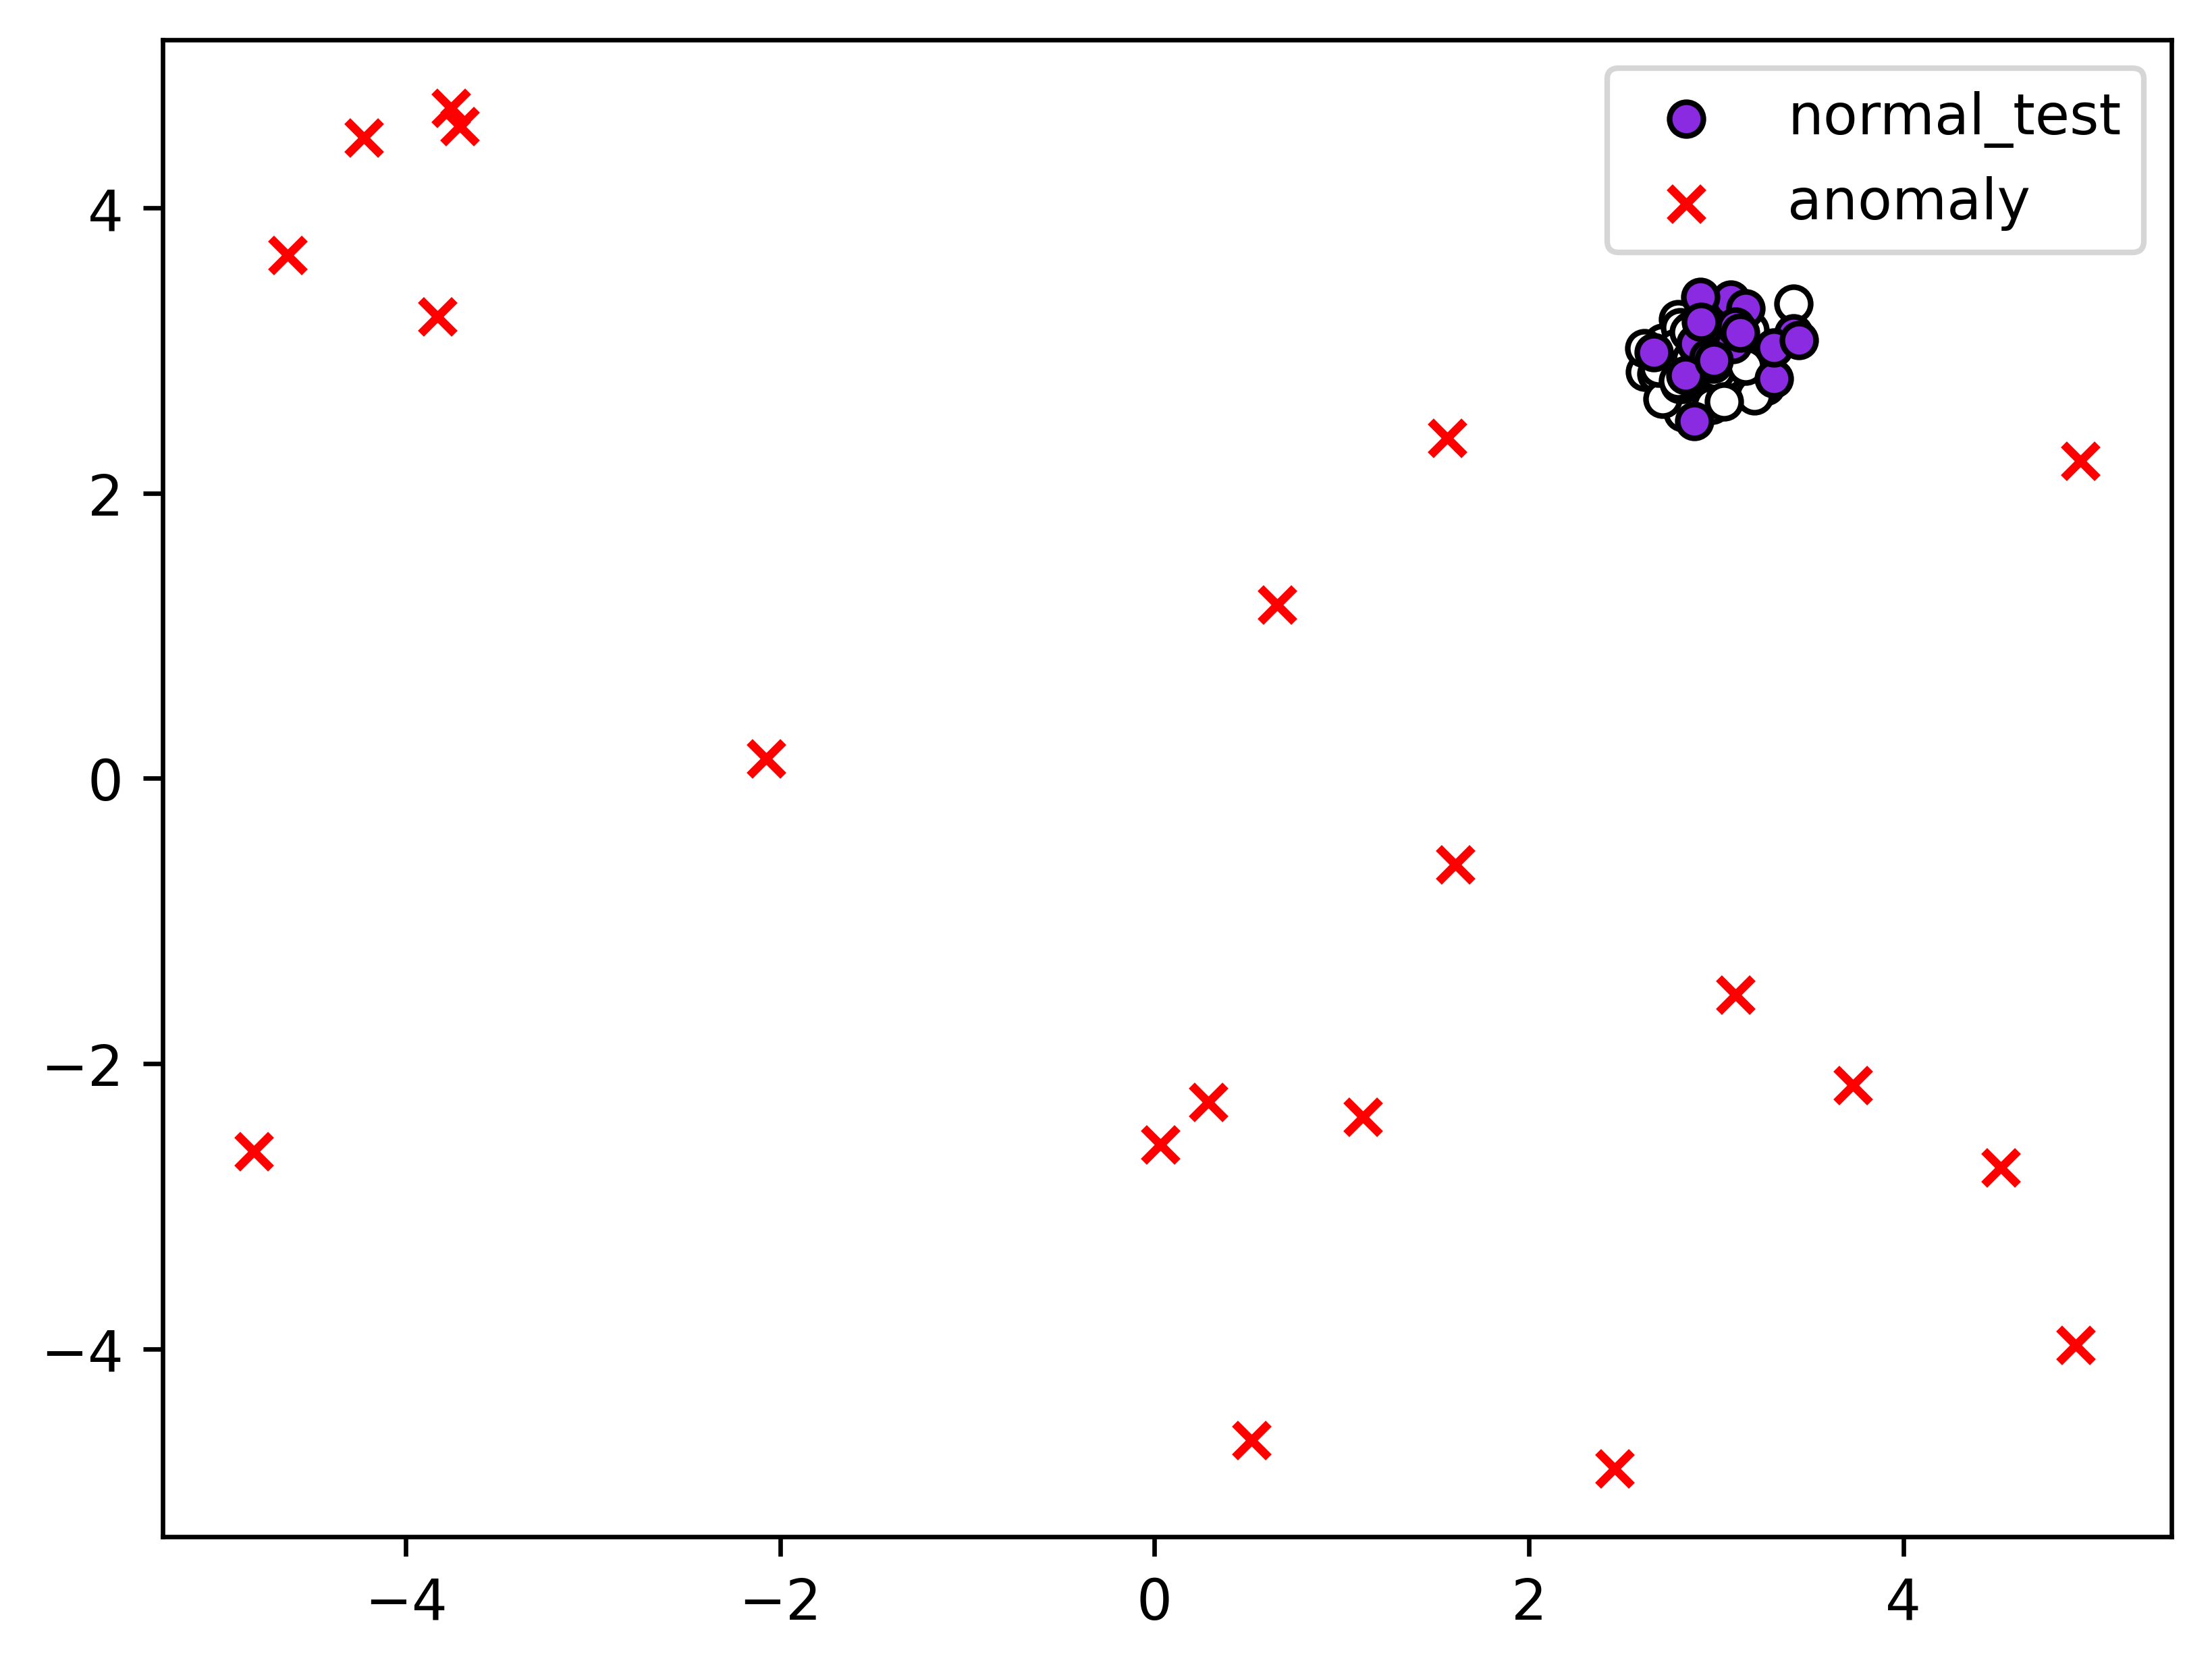

In [45]:
X = 0.2 * np.random.randn(50, 2)
X_train = np.r_[X + 3]
X = 0.2 * np.random.randn(20, 2)
X_test = np.r_[X + 3]
X_outliers = np.random.uniform(low=-5, high=5, size=(20, 2))

plt.scatter(X_train[:, 0], X_train[:, 1], c="white",  edgecolors="k")
plt.scatter(X_test[:, 0], X_test[:, 1], c="blueviolet",  edgecolors="k", label="normal_test")
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c="red", marker='x', label="anomaly")

plt.legend()
plt.show()

In [46]:
from sklearn.ensemble import IsolationForest

isolForest = IsolationForest(n_estimators=300, random_state=33)
isolForest.fit(X_train)

y_pred_train = isolForest.predict(X_train)
y_pred_test = isolForest.predict(X_test)
y_pred_outliers = isolForest.predict(X_outliers)

y_pred_outliers[(y_pred_outliers[:]>0)].shape

(0,)

In [47]:
full_test_outliers = np.column_stack((X_outliers, y_pred_outliers))
print(full_test_outliers)

[[-4.22593544  4.49088346 -1.        ]
 [-4.6309889   3.66837357 -1.        ]
 [ 4.94642224  2.22727725 -1.        ]
 [-3.8321701   3.23852914 -1.        ]
 [-3.7588629   4.70185624 -1.        ]
 [ 0.28784482 -2.27140672 -1.        ]
 [ 1.11316413 -2.37295307 -1.        ]
 [ 0.65606128  1.21633309 -1.        ]
 [-3.71170852  4.57395598 -1.        ]
 [ 3.73099207 -2.15341085 -1.        ]
 [-4.81064534 -2.61654455 -1.        ]
 [ 0.5177992  -4.6406364  -1.        ]
 [ 1.56540171  2.38494778 -1.        ]
 [ 2.45675792 -4.83857615 -1.        ]
 [ 1.60848251 -0.6057095  -1.        ]
 [ 4.92209844 -3.97225734 -1.        ]
 [ 0.03104032 -2.56745091 -1.        ]
 [ 3.10404003 -1.51909059 -1.        ]
 [-2.07634665  0.13905285 -1.        ]
 [ 4.52177803 -2.72943372 -1.        ]]


In [48]:
normal = full_test_outliers[(full_test_outliers[:,2] > 0)]
anomaly = full_test_outliers[(full_test_outliers[:,2] < 0)]
# full_train.sort(axis=0)
# print(full_train.sort())

# valid.sort(axis=0)
# anomaly.sort(axis=0)

print(normal.shape)
print(anomaly.shape)

(0, 3)
(20, 3)


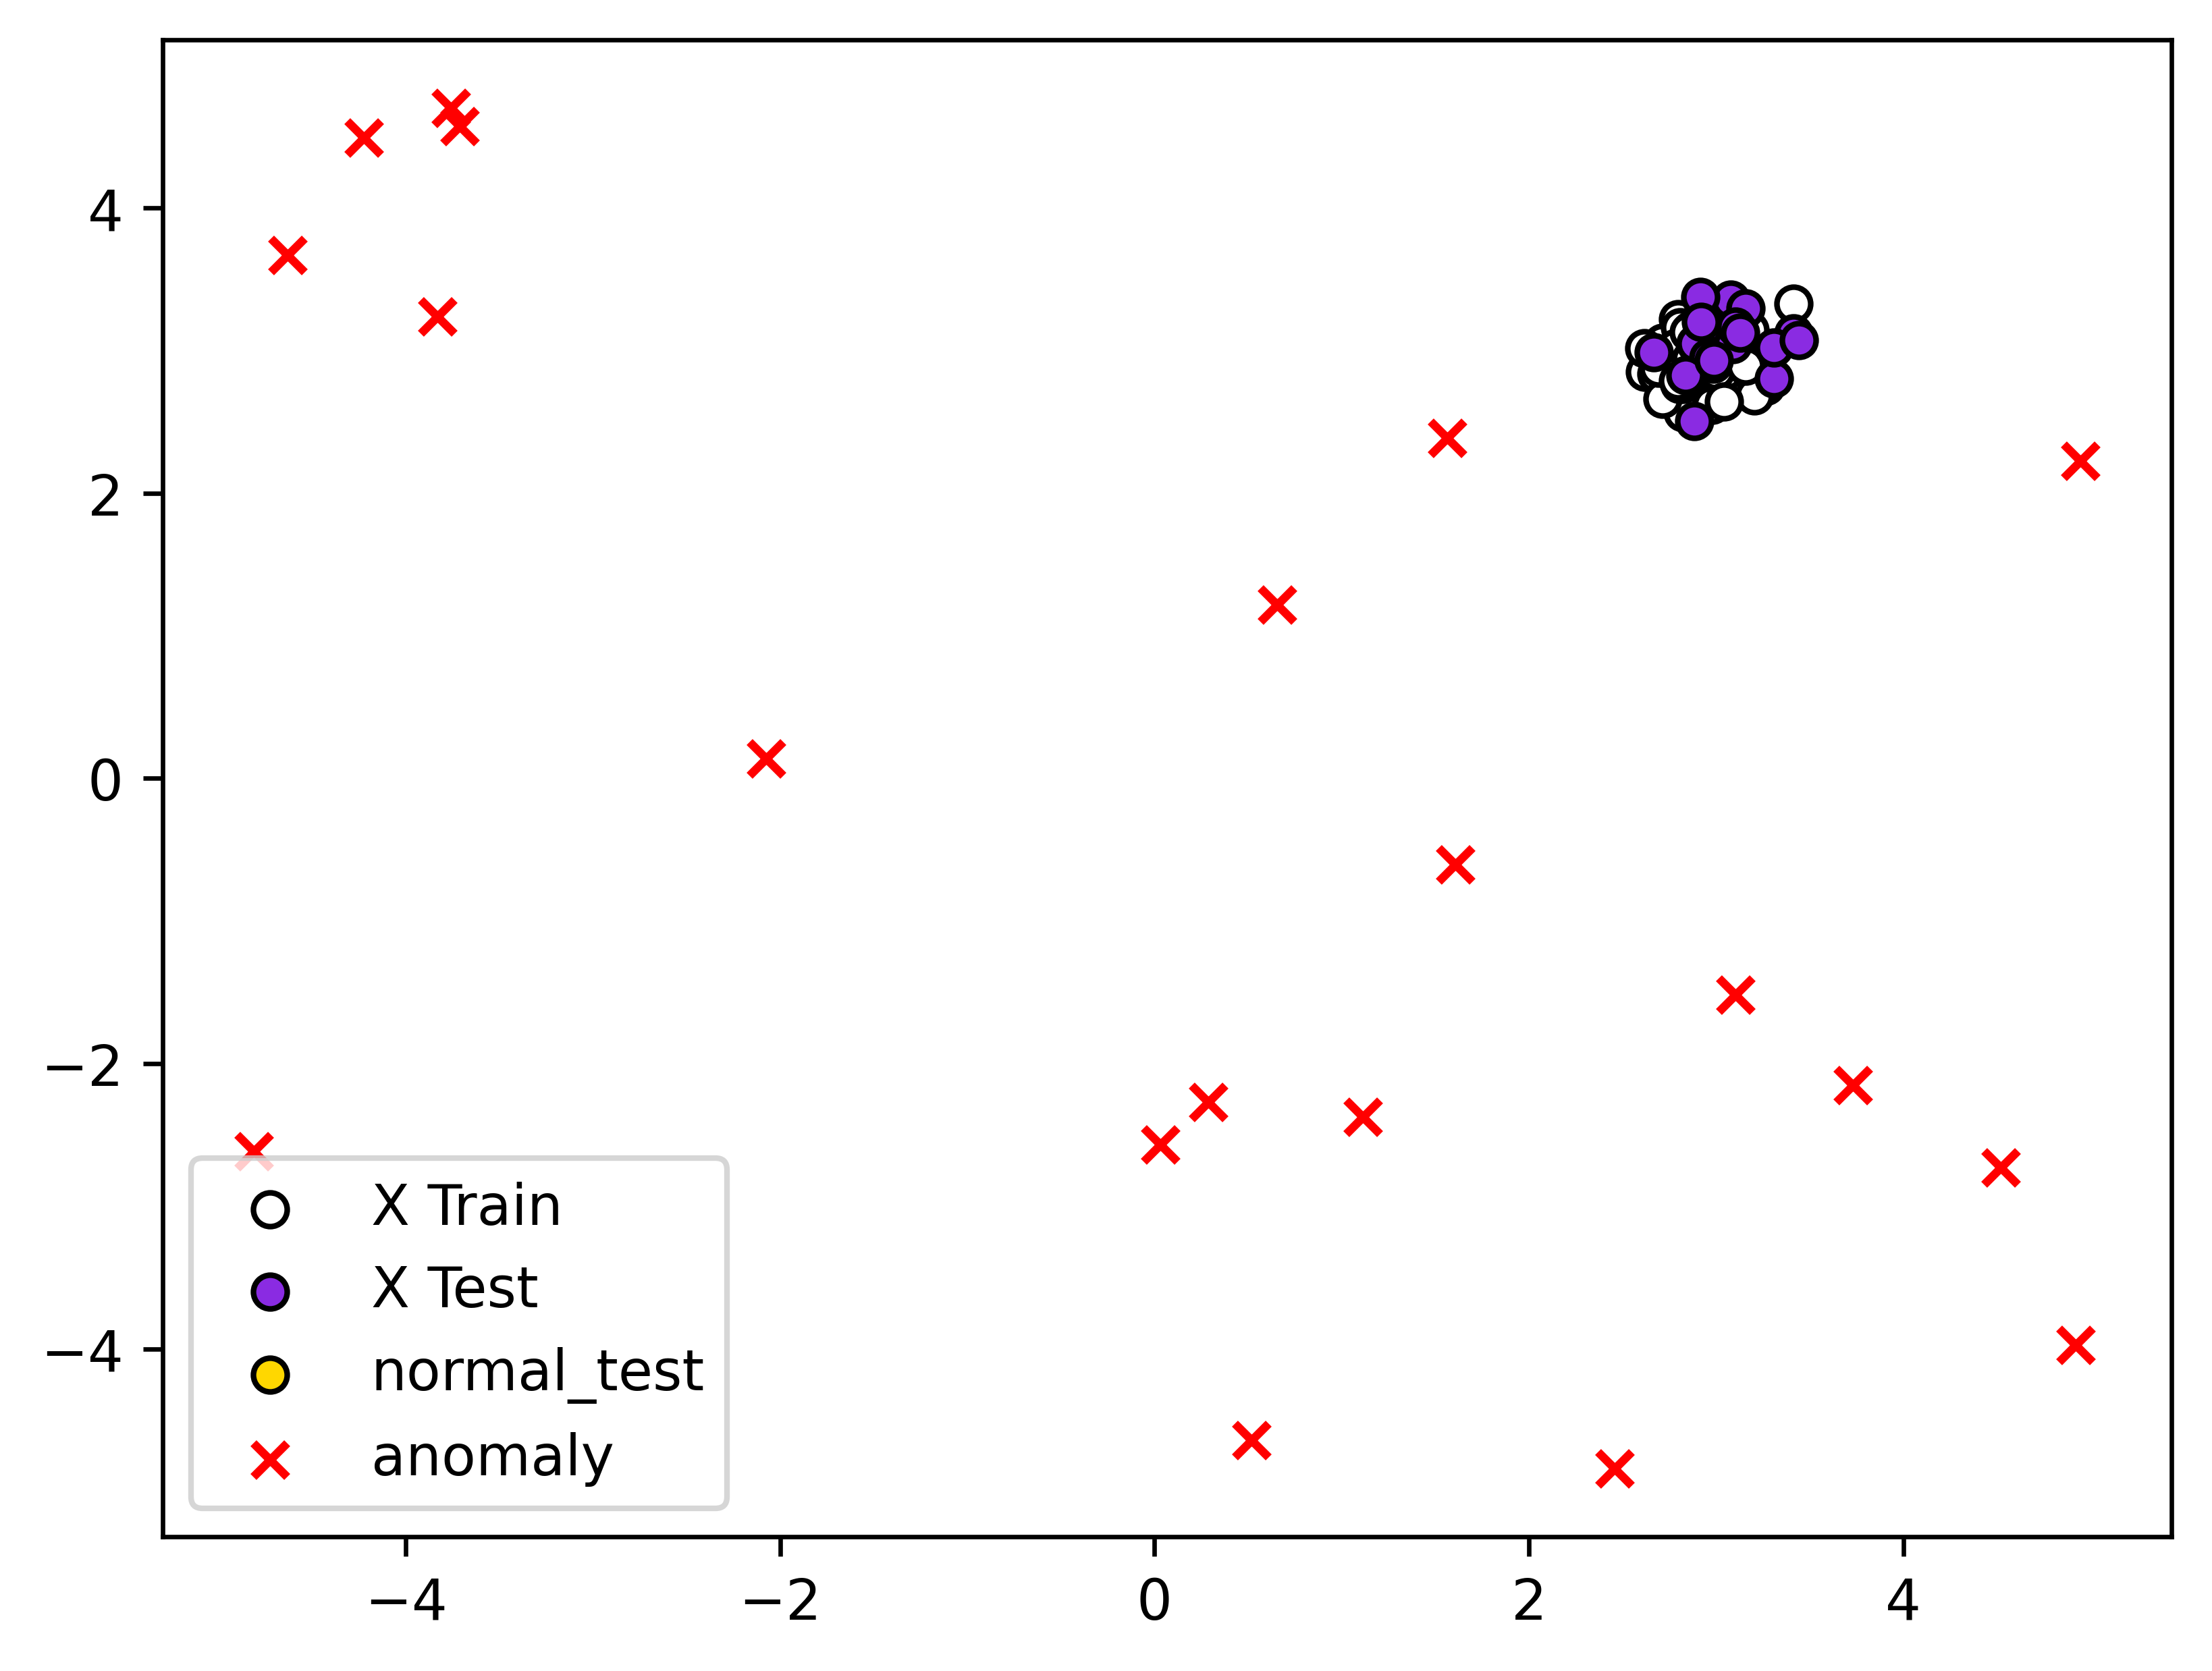

In [49]:
plt.scatter(X_train[:, 0], X_train[:, 1], c="white",  edgecolors="k", label="X Train")
plt.scatter(X_test[:, 0], X_test[:, 1], c="blueviolet",  edgecolors="k", label="X Test")
plt.scatter(normal[:, 0], normal[:, 1], c="gold", edgecolors="k", label="normal_test")
plt.scatter(anomaly[:, 0], anomaly[:,  1], marker="x",color="red", label="anomaly")


plt.legend()
plt.show()

## Clustering

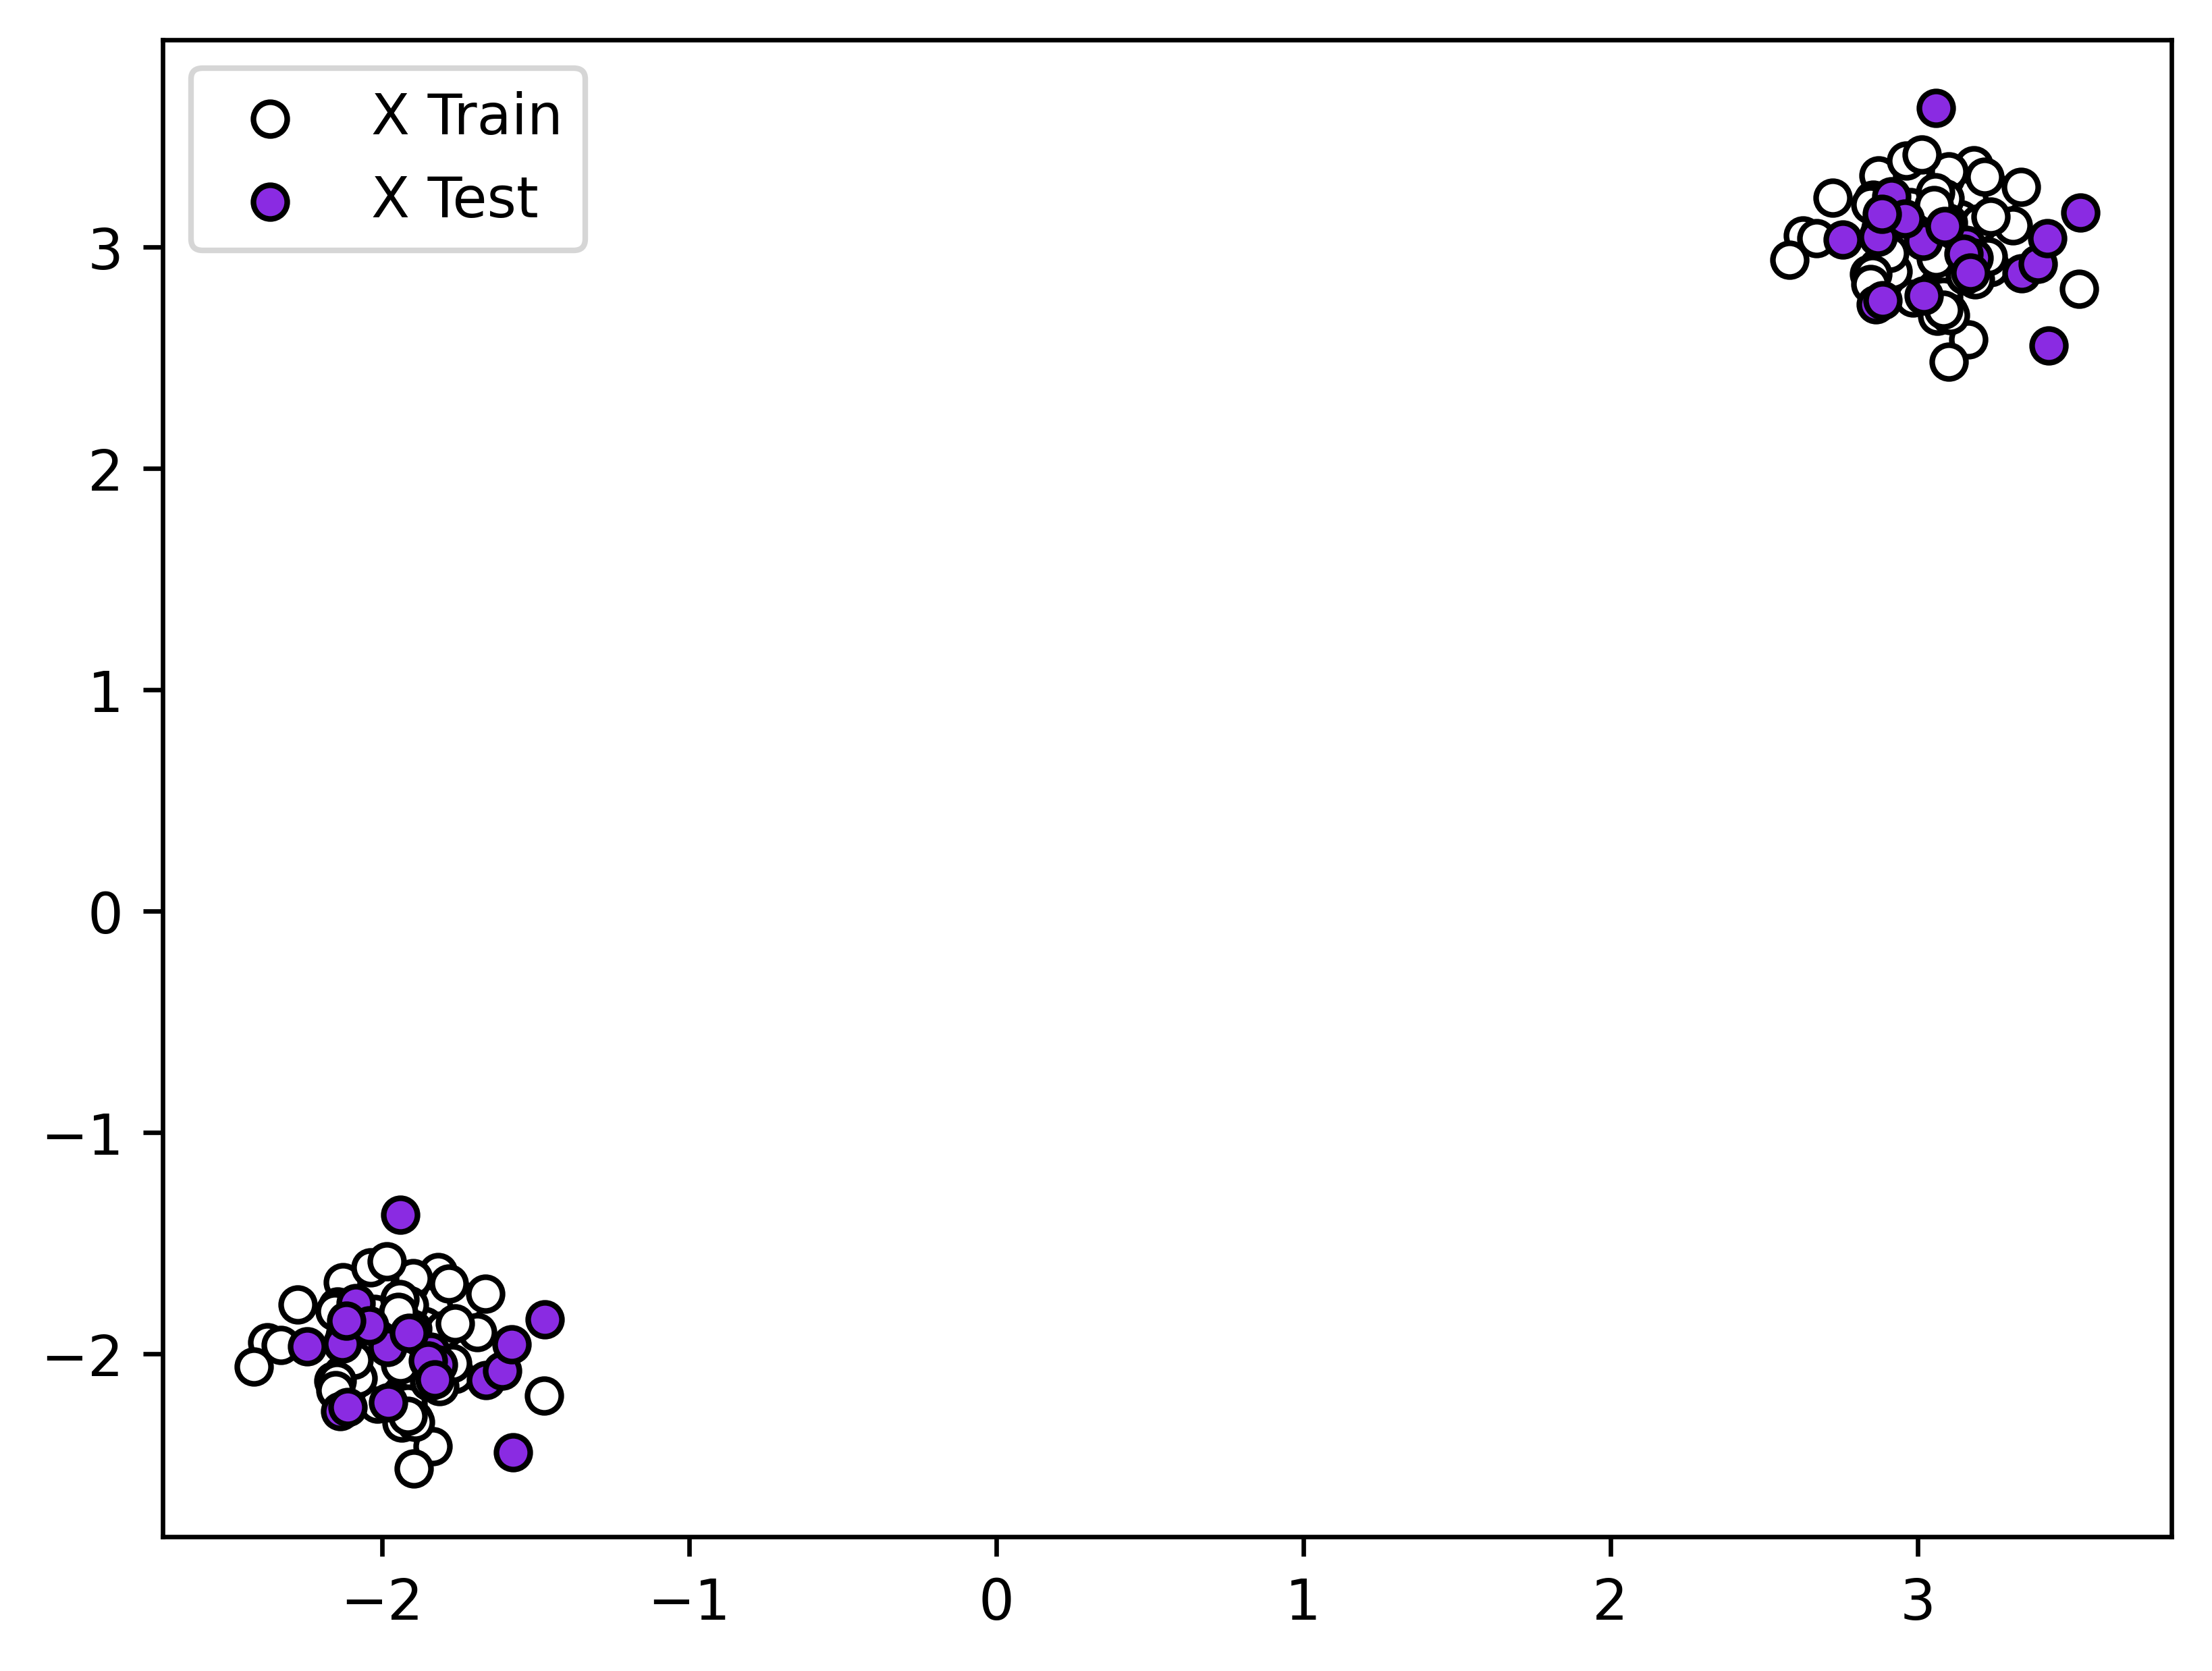

In [50]:
X = 0.2 * np.random.randn(50, 2)
X_train = np.r_[X - 2 , X + 3]
X = 0.2 * np.random.randn(20, 2)
X_test = np.r_[X - 2, X + 3]

plt.scatter(X_train[:, 0], X_train[:, 1], c="white",  edgecolors="k", label="X Train")
plt.scatter(X_test[:, 0], X_test[:, 1], c="blueviolet",  edgecolors="k", label="X Test")

plt.legend()
plt.show()

## DBScan

In [51]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X_train)
db

DBSCAN(eps=0.3, min_samples=10)